In [3]:
!pip install gymnasium

In [2]:
!pip install sb3-contrib

In [4]:
import sys
sys.path.append("/project_ghent/chronocooked")

In [5]:
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator

In [6]:
from singleagent.rl_environments.multitiming_production import MultiTimeProduction

In [7]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, shapiro, levene, ttest_1samp, f_oneway, ttest_rel, mannwhitneyu, kruskal, wilcoxon
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multitest import multipletests

In [8]:

from itertools import combinations


In [9]:
import matplotlib as mpl

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


In [5]:
def plot_traj(obs_concat, act_concat, n_rows):
    arr = np.array(obs_concat)  # (200, 5, 3)

    n_rows = n_rows
    n_cols = len(arr) // n_rows# 40
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,10))
    # fig, axes = plt.subplots(n_rows, n_cols, figsize=(10,2))
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(arr[i], cmap = 'turbo', vmin=0, vmax=9, interpolation='nearest', aspect='auto')
        # ax.text(0.5, -0.6, str(act_concat[i]), fontsize=12)
        # ax.text(0.2, 5.6, str(reward_concat[i]), fontsize=12)
        if reward_concat[i] != 0:
            ax.set_title(f"A:{act_concat[i]} R:{reward_concat[i]}", fontsize=9, fontdict={"color":"red"})
        else:
            ax.set_title(f"A:{act_concat[i]}", fontsize=9)
        # x = ax.set_xticks(x_ticks, [f"{int(l[0])} , {str(l[1])}, {str(l[2])} " for l in zip(act_concat, range(len(act_concat)), reward_concat)], rotation =90, ha='right', fontsize=10)
    
        ax.axis('off')  # hide axes for clarity
    
    plt.tight_layout()
    plt.show()

In [10]:
# seeds
# map seed to each starting point
env = MultiTimeProduction(max_timesteps=200)
seeds = {(int(ax),int(ay)): -1 for ax, ay in zip(np.where(env.reset(seed=0)[0][:,:,0] ==0)[0],np.where(env.reset(seed=0)[0][:,:,0] ==0)[1])}
for s in range(1,30,1):
    ax, ay = np.where(env.reset(seed=s)[0][:,:,1] ==1)
    if seeds[int(ax[0]),int(ay[0])] == -1:
        seeds[int(ax[0]),int(ay[0])] = s
seeds

{(0, 0): 2,
 (1, 0): 14,
 (1, 1): 1,
 (1, 2): 3,
 (2, 1): 13,
 (2, 2): 7,
 (3, 0): 25,
 (3, 1): 9,
 (3, 2): 17,
 (4, 0): 5,
 (4, 1): 19,
 (4, 2): 20}

In [11]:
def get_min_ts_lastlevel(tb_event_file): # for the last level check if models learns task before max timesteps 
    # trainign timesteps needed for new anchor
    ea = event_accumulator.EventAccumulator(tb_event_file)
    ea.Reload()
    
    events = ea.Scalars("rollout/ep_rew_mean")
    
    steps = np.array([e.step for e in events])
    rewards = np.array([e.value for e in events])
    
    drop_fraction = 0.20  # 20%
    
    end_reward = rewards[-1]
    start_idx = 0
    
    if end_reward >=0.8: # get the first timestep where performance drops below 80
        for i in range(len(rewards) - 2, -1, -1):
            if rewards[i] < 0.8:
                start_idx = i + 1
                break
    
    return steps[start_idx]

In [12]:
def get_cl_task_performance(lstm_size=125, ctrnn=False, td_lists=[[2,4,6,8,10]]):
    
    # delivery_counter_used_history = {}
    observation_history = {}
    action_history = {}
    reward_history = {}
    min_training_timesteps = {}
    models_history = {}
    event_files = {}
    rows=[]
       
    ent_coeff = 0
    timestep = 200
    g = 0.99
    for td_list in td_lists:
        duration_list_id = "-".join(map(str, td_list))
        min_training_timesteps[duration_list_id] = {}
        event_files[duration_list_id] = {}
    
        for env_i in range(len(td_list)+1):
            if env_i==0:
                num_timers= 1
                td_subset_str = f"{td_list[0]}_env0" 
            else:
                num_timers = env_i
                td_subset_str = "-".join(map(str, td_list[0:num_timers]))

            # delivery_counter_used_history[anchors_subset_str] = {}
            models_history[td_subset_str] = {}
            observation_history[td_subset_str] = {}
            action_history[td_subset_str] = {}
            reward_history[td_subset_str] = {}
            
            for log in [1,2,3,4]:
    
                models_folder = "/project_ghent/chronocooked/singleagent/train/multitimer_tp_cl_cat_modelsv2"
                if lstm_size is None:
                    model_file = f"v5_cl_cat_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_logs{log}/"
                    model_label = "CNN"
                elif ctrnn:
                    model_file = f"v5_cl_cat_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_ctrnn{lstm_size}_mlp64_gamma{g}_logs{log}/"
                    model_label = f"CTRNN{lstm_size}"
                else:
                    model_file = f"v5_cl_cat_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_logs{log}/"
                    model_label = f"LSTM{lstm_size}"           
                try:
                    model_files = os.listdir(f"{models_folder}/{model_file}")
                    
                except:
                    print("no such dir",f"{models_folder}/{model_file}" )
                    continue
                    
                # get min timesteps needed for last level of curriculum leanring 
                tb_event_file = [f"{models_folder}/{model_file}/{mod_file}" for mod_file in model_files if "env" not in mod_file][0]
                min_ts_lastlevel = get_min_ts_lastlevel(tb_event_file)
                event_files[duration_list_id][log] = tb_event_file
                # print(min_ts_lastlevel)
                
                # get timesteps correspondign to transition to next level of curriculum learning 
                max_training_ts_envi = max([int(mod_file.split("env")[1].split("_")[1])  if ("env" in mod_file) and (mod_file.split("env")[1].split("_")[0] == str(env_i)) else 0 for mod_file in model_files])
                
                if (num_timers == len(td_list)) and (min_ts_lastlevel>1000):
                    min_training_timesteps[duration_list_id][log] =  min_training_timesteps[duration_list_id].get(log, []) + [min_ts_lastlevel]
                else:
                    min_training_timesteps[duration_list_id][log] =  min_training_timesteps[duration_list_id].get(log, []) + [max_training_ts_envi]
                
                # delivery_counter_used_history[anchors_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                models_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                observation_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                action_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = {}
                reward_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = {}

                if env_i ==0:
                   env_test = MultiTimeProduction(oven_duration_list=td_list, max_timesteps=timestep, num_timers=1,
                                reduced_reward=0.1, overcooked_buffer=0, undercooked_buffer=0, undercooked_possible=False)
                else:
                    env_test = MultiTimeProduction(oven_duration_list=td_list, max_timesteps=timestep, num_timers=num_timers,
                                    reduced_reward=0.1, overcooked_buffer=0, undercooked_buffer=2, undercooked_possible=True)
                
                try:
                    if lstm_size is None:
                        model = PPO.load(f"{models_folder}/{model_file}/rl_model_env{env_i}_{max_training_ts_envi}_steps.zip", 
                                         env=env_test)
                    else:
                        model = RecurrentPPO.load(f"{models_folder}/{model_file}/rl_model_env{env_i}_{max_training_ts_envi}_steps.zip", env=env_test)
                except:
                    print(f"could not load model, {models_folder}/{model_file}/rl_model_env{env_i}_{max_training_ts_envi}_steps.zip")
                    continue 
                    
                # for td in range(1,td_list[num_timers-1]+2):
                for td in td_list[:num_timers]:
                    

                    td_observations = []
                    td_actions = []
                    td_rewards = []
                    
    
                    for seed in seeds.values():    
                        obs, _ = env_test.reset(seed=seed, oven_duration=td)
                        visual_obs = np.sum(obs,axis=2)
                        obs_concat = [visual_obs]
                        act_concat = []
                        reward_concat = []
                        # print("oven timers", env_test.oven1_timer, env_test.oven2_timer)
                        rewards=0
                        states = None
                        
                        for i in range(timestep + 2):
                            # obs = obs + 300
                            action, states = model.predict(obs, state=states, deterministic=True) 
                            act_concat.append(action)
                            # print(visual_obs)
                            # print("action",action)
                            obs, reward, done, _ ,_= env_test.step(action)
                            visual_obs = np.sum(obs,axis=2)
                            obs_concat.append(visual_obs)
                        
                            # print("reward",reward)
                            # print("oven timer", env_test.oven_timer)
                            
                            rewards += reward
                            reward_concat.append(reward)
                            if done:
                                reward_concat.append(reward)
                                act_concat.append(0)
                                td_observations.append(obs_concat)
                                td_actions.append(act_concat)
                                td_rewards.append(reward_concat)
                                rows.append({"duration_list_id":duration_list_id,  "model":model_label,
                                             "td_subset_str":td_subset_str, "Cl_stage":env_i, "num_timers":num_timers,"TD":td, 
                                            "log":log, "seed":seed,
                                            "reward":reward, "oven_off_time":env_test.oven_off_time, 
                                            "delta_oven_off":env_test.oven_off_time - td,
                                            
                                            })
                                
                                # obs,_ = env_test.reset()                    
                                # print("short_duration", short_duration, "long_duration", long_duration, "rewards",rewards, "delivery counter", env_test.delivery_counter_used, i+1)
                                break
                    observation_history[td_subset_str][f"{log}-{max_training_ts_envi}"][td] = td_observations
                    action_history[td_subset_str][f"{log}-{max_training_ts_envi}"][td] = td_actions
                    reward_history[td_subset_str][f"{log}-{max_training_ts_envi}"][td] = td_rewards
                models_history[td_subset_str][f"{log}-{max_training_ts_envi}"] = dict(model.policy.named_parameters())
                    
    
    performance_history_df = pd.DataFrame(rows)
    return performance_history_df, min_training_timesteps , event_files, models_history, observation_history, action_history, reward_history


In [13]:
performance_history_df125, min_training_timesteps125, event_files125, models_history125, observation_history125, action_history125, reward_history125 = get_cl_task_performance(lstm_size=125, ctrnn=False, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

In [14]:
performance_history_df256, min_training_timesteps256, event_files256, models_history256, observation_history256, action_history256, reward_history256 = get_cl_task_performance(lstm_size=256, ctrnn=False, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

In [32]:
min_training_timesteps256

{'2-4-6-8-10': {1: [134000, 137000, 149000, 178000, 226000, np.int64(1744000)],
  2: [41000, 46000, 1754000, 0, 0, np.int64(1750000)],
  3: [100000, 104000, 639000, 1107000, 1130000, np.int64(1496000)],
  4: [203000, 206000, 211000, 1626000, 1665000, np.int64(1759000)]},
 '3-6-9-12-15': {1: [52000, 57000, 99000, 1079000, 1188000, 1750000],
  2: [92000, 96000, 104000, 257000, 298000, np.int64(1686000)],
  3: [138000, 141000, 158000, 180000, 253000, 1750000],
  4: [43000, 48000, 86000, 263000, 284000, np.int64(1742000)]}}

In [15]:
performance_history_df8, min_training_timesteps8, event_files8, models_history8, observation_history8, action_history8, reward_history8 = get_cl_task_performance(lstm_size=8, ctrnn=False, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

In [41]:
min_training_timesteps8

{'2-4-6-8-10': {1: [76000, 78000, 87000, 107000, 109000, 1750000],
  2: [67000, 70000, 107000, 112000, 145000, 1750000],
  3: [93000, 96000, 119000, 124000, 129000, 1750000],
  4: [153000, 157000, 194000, 1315000, 1342000, 1750000]},
 '3-6-9-12-15': {1: [31000, 33000, 57000, 66000, 83000, 1750000],
  2: [71000, 74000, 158000, 175000, 192000, 1750000],
  3: [164000, 166000, 217000, 236000, 283000, 1750000],
  4: [39000, 42000, 79000, 92000, 111000, 1750000]}}

In [16]:
performance_history_df_ctrnn125, min_training_timesteps_ctrnn125, event_files_ctrnn125, models_history_ctrnn125, observation_history_ctrnn125, action_history_ctrnn125, reward_history_ctrnn125 = get_cl_task_performance(lstm_size=125, ctrnn=True, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

In [17]:
performance_history_df_ctrnn256, min_training_timesteps_ctrnn256, event_files_ctrnn256, models_history_ctrnn256, observation_history_ctrnn256, action_history_ctrnn256, reward_history_ctrnn256 = get_cl_task_performance(lstm_size=256, ctrnn=True, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

In [18]:
performance_history_df_ctrnn8, min_training_timesteps_ctrnn8, event_files_ctrnn8, models_history_ctrnn8, observation_history_ctrnn8, action_history_ctrnn8, reward_history_ctrnn8 = get_cl_task_performance(lstm_size=8, ctrnn=True, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

In [42]:
min_training_timesteps_ctrnn8

{'2-4-6-8-10': {1: [116000,
   120000,
   979000,
   1049000,
   1133000,
   np.int64(1717000)],
  2: [191000, 195000, 973000, 1224000, 1297000, np.int64(1449000)],
  3: [163000, 166000, 664000, 755000, 851000, np.int64(1278000)],
  4: [128000, 132000, 706000, 882000, 925000, np.int64(1439000)]},
 '3-6-9-12-15': {1: [823000,
   827000,
   1443000,
   1463000,
   1554000,
   np.int64(1727000)],
  2: [265000, 272000, 576000, 718000, 924000, np.int64(1214000)],
  3: [1454000, 1465000, 1750000, 0, 0, 0],
  4: [1750000, 0, 0, 0, 0, 0]}}

In [19]:
performance_history_df_cnn, min_training_timesteps_cnn, event_files_ctrnn8, models_history_cnn, observation_history_cnn, action_history_cnn, reward_history_cnn = get_cl_task_performance(lstm_size=None, ctrnn=False, td_lists=[[2,4,6,8,10],[3,6,9,12,15]]) 

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
could not load model, /project_ghent/chronocooked/singleagent/train/multitim

# num of parameters

In [40]:
models_history125['2_env0']['3-101000']['lstm_actor.weight_hh_l0'].shape

torch.Size([500, 125])

In [46]:
lstm_params = sum(
    tensor.numel()
    for name, tensor in models_history125['2_env0']['3-101000'].items()
    if name.startswith("lstm_actor.")
)

print(lstm_params)

95500


In [25]:
# number of parameters
for model_history in [models_history8, models_history125, models_history256, models_history_ctrnn8, models_history_ctrnn125, models_history_ctrnn256]:
    ts = list(model_history['2_env0'].keys())[0]
    ctrnn_params = sum(
        tensor.numel()
        for name, tensor in model_history['2_env0'][ts].items()
        if name.startswith("lstm_actor.")
    )
    
    print(ctrnn_params)

2368
95500
329728
592
23875
82432


In [18]:
min_training_timesteps125, min_training_timesteps_ctrnn125

({'2-4-6-8-10': {1: [78000, 81000, 103000, 125000, 131000, np.int64(983000)],
   2: [125000, 129000, 181000, 193000, 233000, 1750000],
   3: [89000, 93000, 119000, 139000, 147000, np.int64(1372000)],
   4: [37000, 41000, 81000, 276000, 292000, np.int64(691000)]}},
 {'2-4-6-8-10': {1: [170000,
    173000,
    374000,
    412000,
    426000,
    np.int64(1566000)],
   2: [67000, 71000, 277000, 291000, 316000, np.int64(1287000)],
   3: [204000, 207000, 366000, 396000, 430000, np.int64(1132000)],
   4: [327000, 331000, 486000, 522000, 542000, np.int64(1708000)]}})

In [23]:
performance_history_df125.groupby(["td_subset_str","log"])[["reward","oven_off_time"]].mean()

reward  oven_off_time
td_subset_str log                         
2             1    1.000000       1.000000
              2    1.000000       1.000000
              3    1.000000       1.000000
              4    1.000000       1.000000
2-4           1    0.850000       1.716667
              2    0.788333       1.633333
              3    0.820000       1.583333
              4    0.820000       1.583333
2-4-6         1    0.964286       2.952381
              2    0.954762       2.892857
              3    0.827381       2.571429
              4    0.833333       2.892857
2-4-6-8       1    0.940741       3.861111
              2    0.850000       3.583333
              3    0.890741       3.629630
              4    0.940741       3.740741
2-4-6-8-10    1    0.918182       4.681818
              2    0.000000      -1.000000
              3    0.843182       4.712121
              4    0.890909       4.590909
2_env0        1    1.000000       2.000000
              2    1.000000       2.000000
              3    0.833333       1.500000
              4    0.583333       0.750000

In [19]:
performance_history_df8.groupby(["td_subset_str","log"])[["reward","oven_off_time"]].mean()

reward  oven_off_time
td_subset_str log                         
2             1    0.833333       0.666667
              2    0.416667      -0.166667
              3    0.916667       0.833333
              4    0.833333       0.666667
2-4           1    0.820000       1.566667
              2    1.000000       1.833333
              3    0.866667       2.033333
              4    0.480000       1.350000
2-4-6         1    0.895238       2.119048
              2    0.857143       1.714286
              3    0.957143       2.773810
              4    0.742857       2.595238
2-4-6-8       1    0.833333       2.777778
              2    0.525926       1.657407
              3    0.958333       3.666667
              4    0.733333       3.712963
2-4-6-8-10    1    0.000000      -1.000000
              2    0.000000      -1.000000
              3    0.000000      -1.000000
              4    0.070455      -0.469697
2_env0        1    0.833333       1.500000
              2    0.416667       0.250000
              3    0.666667       1.000000
              4    0.833333       1.500000

In [29]:
performance_history_df125[performance_history_df125["num_timers"]==3][0:50]

,duration_list_id,model,td_subset_str,Cl_stage,num_timers,TD,log,seed,reward,oven_off_time,delta_oven_off
132,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,2,0.0,1,0
133,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,14,0.0,1,0
134,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,1,0.0,1,0
135,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,3,0.0,1,0
136,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,13,0.0,1,0
137,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,7,1.0,1,0
138,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,25,0.0,1,0
139,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,9,0.0,1,0
140,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,17,0.0,1,0
141,2-4-6-8-10,LSTM125,2-4-6,3,3,1,1,5,1.0,1,0


# Oven time comparison

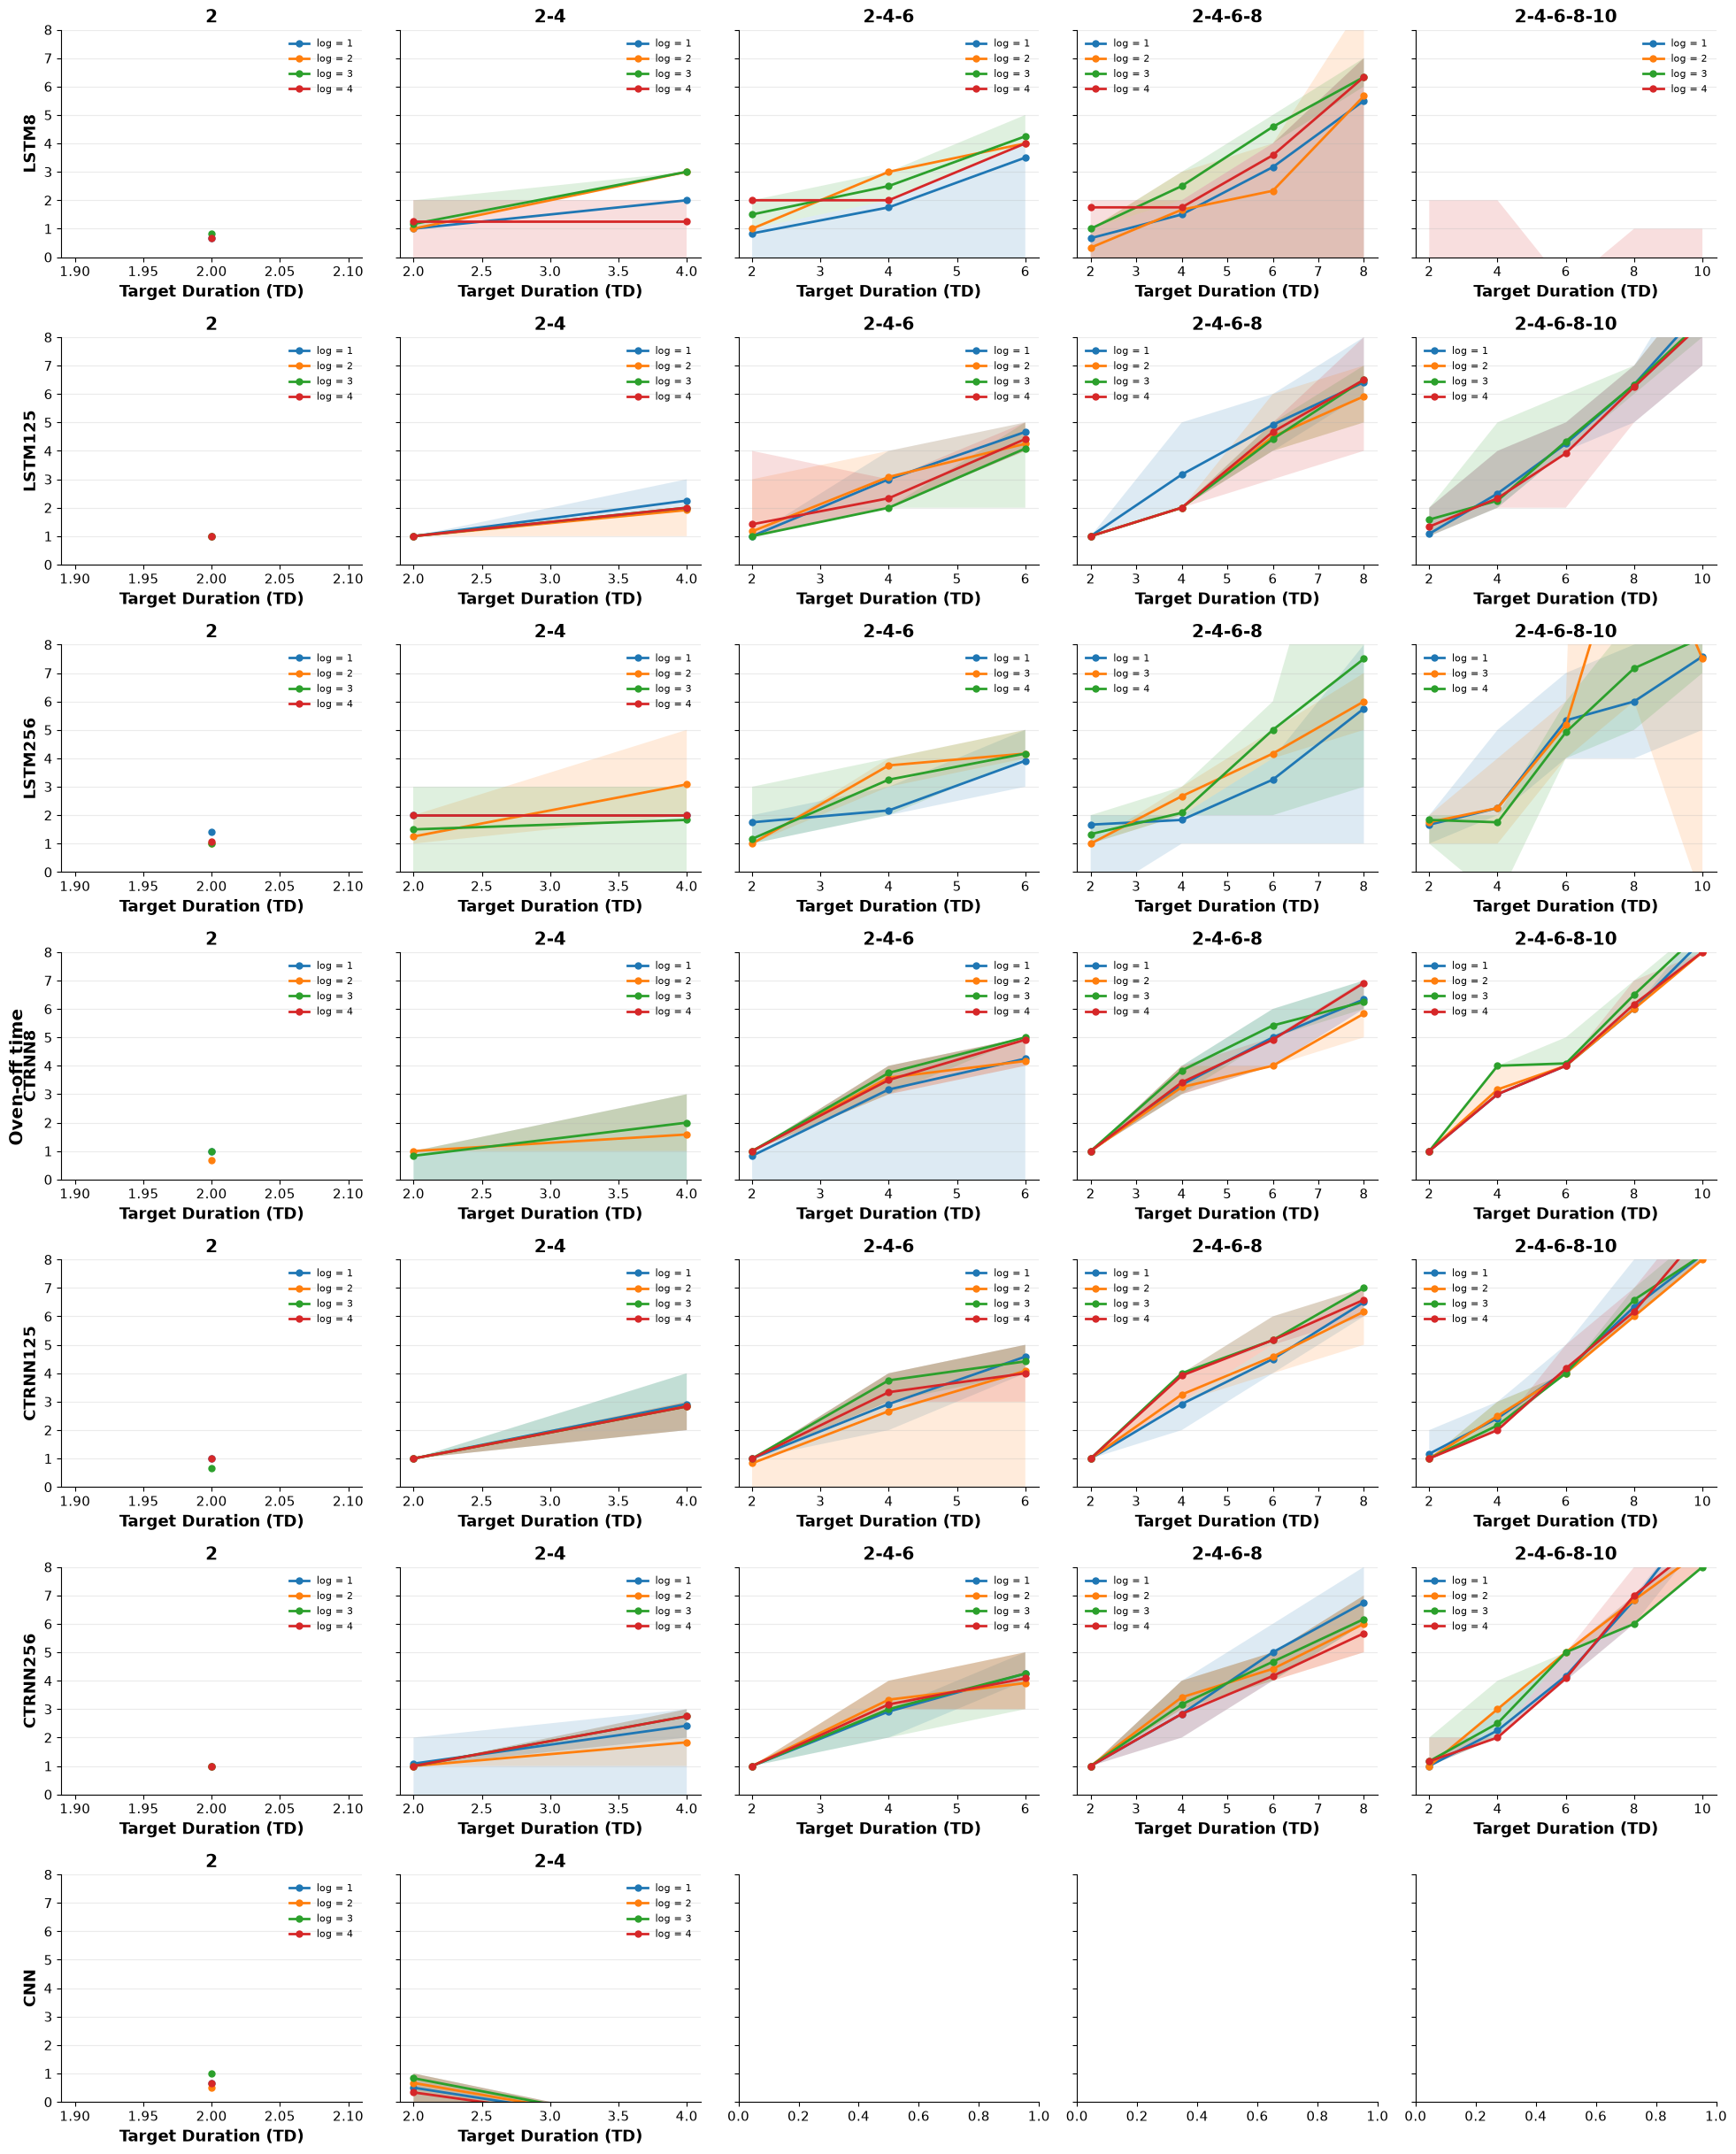

In [16]:
results_list = [performance_history_df8, performance_history_df125, performance_history_df256,
               performance_history_df_ctrnn8, performance_history_df_ctrnn125, performance_history_df_ctrnn256, performance_history_df_cnn]


model_names = [
    "LSTM8",
    "LSTM125",
    "LSTM256",
    "CTRNN8",
    "CTRNN125",
    "CTRNN256",
    "CNN"
]


# results_list = [performance_history_df125,
#                performance_history_df_ctrnn125, performance_history_df_cnn]

# model_names = [

#     "LSTM125",
#     "CTRNN125",

#     "CNN"
# ]

# Get all td_subsets across all results first
all_td_subsets = sorted(
    set(
        td_subset
        for performance_df in results_list
        for td_subset in performance_df["td_subset_str"].unique()
    )
)

n_rows = len(results_list)
n_cols = len(all_td_subsets) -1

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.5 * n_rows),
    sharey=True,
    squeeze=False
)
 

for row_i, performance_df in enumerate(results_list):

    performance_df =performance_df[performance_df["Cl_stage"]>0]
    performance_df=performance_df[performance_df["TD"].isin([2,4,6,8,10])]
    summary = (
        performance_df.groupby(["td_subset_str", "log", "TD"])["oven_off_time"]
          .agg(
              mean="mean",
              min="min",
              max="max"
          )
          .reset_index()
    )
    
    # ------------------------------------------------------------
    # Plot: one column per td_subset_str
    # ------------------------------------------------------------
    
    td_subsets = sorted(summary["td_subset_str"].unique())
    

    
    for col_i, td_subset in enumerate(td_subsets):
        if len(results_list) ==1:
            ax=axes[col_i]
        else:
            ax=axes[row_i, col_i]
    
        subset = summary[
            summary["td_subset_str"] == td_subset
        ]
    
        # One line for each log
        for log in sorted(subset["log"].unique()):
    
            data = (
                subset[subset["log"] == log]
                .sort_values("TD")
            )
    
            x = data["TD"].to_numpy()
            mean = data["mean"].to_numpy()
            lower = data["min"].to_numpy()
            upper = data["max"].to_numpy()
    
            # Min-max shaded region across seeds
            ax.fill_between(
                x,
                lower,
                upper,
                alpha=0.15
            )
    
            # Mean across seeds
            ax.plot(
                x,
                mean,
                marker="o",
                linewidth=2,
                markersize=5,
                label=f"log = {log}"
            )
    
        ax.set_title(
            td_subset,
            fontweight="bold"
        )
    
        ax.set_xlabel(
            "Target Duration (TD)",
            fontweight="bold"
        )
    
        ax.grid(
            axis="y",
            alpha=0.25
        )
    
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    
        ax.legend(
            frameon=False,
            fontsize=8
        )
        ax.set_ylim(0,8)
    axes[row_i, 0].set_ylabel(
    model_names[row_i],
    fontweight="bold"
    )


fig.supylabel(
    "Oven-off time",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# reward in last stage 

      model  mean_reward  sd_reward
0     LSTM8     0.031250   0.174448
1   LSTM125     0.721875   0.446089
2   LSTM256     0.930556   0.242446
3    CTRNN8     1.000000   0.000000
4  CTRNN125     1.000000   0.000000
5  CTRNN256     1.000000   0.000000
6       CNN          NaN        NaN


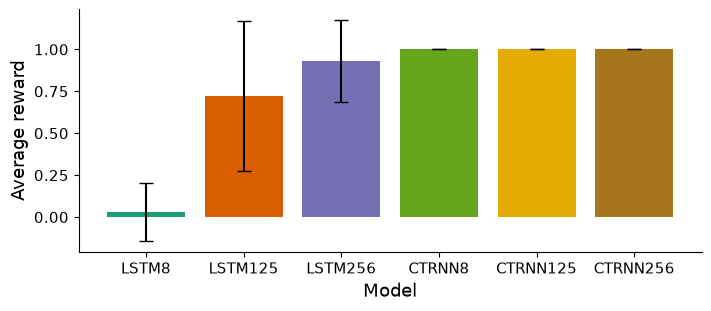

In [82]:
results_list = [
    performance_history_df8,
    performance_history_df125,
    performance_history_df256,
    performance_history_df_ctrnn8,
    performance_history_df_ctrnn125,
    performance_history_df_ctrnn256,
    performance_history_df_cnn
]

model_names = [
    "LSTM8",
    "LSTM125",
    "LSTM256",
    "CTRNN8",
    "CTRNN125",
    "CTRNN256",
    "CNN"
]

# --------------------------------------------------
# Filter and calculate mean + SD for each model
# --------------------------------------------------

target_td = "2-4-6-8-10"

summary = []

for df, model in zip(results_list, model_names):

    filtered = df[df["td_subset_str"] == target_td]

    summary.append({
        "model": model,
        "mean_reward": filtered["reward"].mean(),
        "sd_reward": filtered["reward"].std()
    })

summary_df = pd.DataFrame(summary)

print(summary_df)


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 3), constrained_layout=True)

# dark2 colors
colors = plt.cm.Dark2(np.linspace(0, 1, len(summary_df)))

bars = ax.bar(
    summary_df["model"],
    summary_df["mean_reward"],
    # width=0.2,
    yerr=summary_df["sd_reward"],
    capsize=5,
    color=colors,
    # edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("Model")
ax.set_ylabel("Average reward")
# ax.set_title(f"Average reward for {target_td}")


plt.show()

In [29]:
performance_history_df125

,duration_list_id,model,td_subset_str,Cl_stage,num_timers,TD,log,seed,reward,oven_off_time,delta_oven_off
0,2-4-6-8-10,LSTM125,2-4,2,2,2,1,2,1.0,1,-1
1,2-4-6-8-10,LSTM125,2-4,2,2,2,1,14,1.0,1,-1
2,2-4-6-8-10,LSTM125,2-4,2,2,2,1,1,1.0,1,-1
3,2-4-6-8-10,LSTM125,2-4,2,2,2,1,3,1.0,1,-1
4,2-4-6-8-10,LSTM125,2-4,2,2,2,1,13,1.0,1,-1
...,...,...,...,...,...,...,...,...,...,...,...
955,3-6-9-12-15,LSTM125,3-6-9-12-15,5,5,12,4,9,0.0,-1,-13
956,3-6-9-12-15,LSTM125,3-6-9-12-15,5,5,12,4,17,0.0,-1,-13
957,3-6-9-12-15,LSTM125,3-6-9-12-15,5,5,12,4,5,0.0,-1,-13
958,3-6-9-12-15,LSTM125,3-6-9-12-15,5,5,12,4,19,0.0,-1,-13


# reward across cl stages


Valid td_subset_str values:
['2-4-6-8', '2-4-6-8-10']

Valid td_subset_str values:
['3-6-9-12', '3-6-9-12-15']


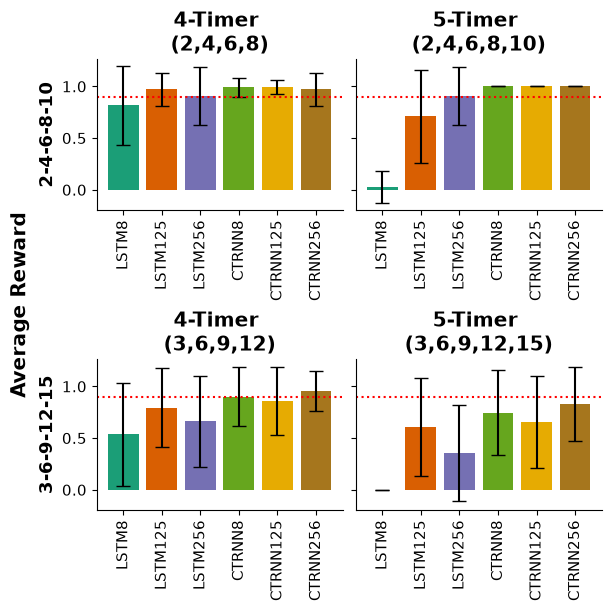

In [21]:
results_list = [
    performance_history_df8,
    performance_history_df125,
    performance_history_df256,
    performance_history_df_ctrnn8,
    performance_history_df_ctrnn125,
    performance_history_df_ctrnn256,
    performance_history_df_cnn
]

model_names = [
    "LSTM8",
    "LSTM125",
    "LSTM256",
    "CTRNN8",
    "CTRNN125",
    "CTRNN256",
    "CNN"
]

# --------------------------------------------------
# Calculate mean + SD for each model and td_subset_str
# --------------------------------------------------

summary = []

for df, model in zip(results_list, model_names):
    for duration_list in df["duration_list_id"].unique():
        parts = duration_list.split("-")
        
        td_sub_strs = ["-".join(parts[:i]) for i in range(1, len(parts) + 1)]

        for td in td_sub_strs:
    
            filtered = df[
                (df["duration_list_id"] == duration_list) &
                (df["td_subset_str"] == td)
            ]

            rewards = filtered["reward"].dropna()
    
            # Only include if this model has data for this td
            if not rewards.empty:
                summary.append({
                    "model": model,
                    "duration_list": duration_list,
                    "td_subset_str": td,
                    "mean_reward": rewards.mean(),
                    "sd_reward": rewards.std(),
                    "n": rewards.size
                })

summary_df = pd.DataFrame(summary)
summary_df["architecture"] = (
    summary_df["model"].str.extract(r"^(LSTM|CTRNN|CNN)")
)
duration_lists = summary_df["duration_list"].unique()
# n_cols = max(len(x.split("-"))-1 for x in duration_lists)
n_cols = 2

fig, axes = plt.subplots(
    len(duration_lists), n_cols,
    figsize=(6,6),
    constrained_layout=True,
    squeeze=False,
    sharey=True
)

cmap = plt.cm.Dark2
colors = [cmap(i) for i in np.linspace(0,1, len(model_names))]

color_map = dict(zip(model_names, colors))

for row, duration_list in enumerate(duration_lists):

    parts = duration_list.split("-")
    td_sub_strs = ["-".join(parts[:i]) for i in range(1, len(parts) + 1)]

    # valid_td_sub_strs = [
    # td for td in td_sub_strs
    # if td in summary_df["td_subset_str"].values
    # ]

    valid_td_sub_strs = [
    td for td in td_sub_strs
    if len(td.split("-"))>3
    ]
    print("\nValid td_subset_str values:")
    print(valid_td_sub_strs)

    for col, td in enumerate(valid_td_sub_strs):

        ax = axes[row, col]

        plot_df = summary_df[
            (summary_df["duration_list"] == duration_list) &
            (summary_df["td_subset_str"] == td)
        ].copy()

        plot_df["model"] = pd.Categorical(
            plot_df["model"],
            categories=model_names,
            ordered=True
        )
        plot_df = plot_df.sort_values("model")

        ax.bar(
            plot_df["model"],
            plot_df["mean_reward"],
            yerr=plot_df["sd_reward"],
            capsize=5,
            color=[color_map[m] for m in plot_df["model"].unique()],
            linewidth=0.8
        )

        ax.axhline(0.9, color="red", linestyle=":", linewidth=1.5)
        ax.set_title(f"{len(td.split("-"))}-Timer \n({",".join([ti for ti in td.split("-")])})", fontweight="bold")
        ax.tick_params(axis="x", rotation=90)

    # Hide unused columns
    for col in range(len(td_sub_strs), n_cols):
        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(duration_list, fontweight="bold")

fig.supylabel("Average Reward", fontweight="bold")
plt.savefig("multitimer_task_performance_cat.pdf",bbox_inches="tight" )
plt.show()


In [57]:
results[model], anchor

({'2-4-6-8-10': {1: [76000, 78000, 87000, 107000, 109000, 1750000],
   2: [67000, 70000, 107000, 112000, 145000, 1750000],
   3: [93000, 96000, 119000, 124000, 129000, 1750000],
   4: [153000, 157000, 194000, 1315000, 1342000, 1750000]},
  '3-6-9-12-15': {1: [31000, 33000, 57000, 66000, 83000, 1750000],
   2: [71000, 74000, 158000, 175000, 192000, 1750000],
   3: [164000, 166000, 217000, 236000, 283000, 1750000],
   4: [39000, 42000, 79000, 92000, 111000, 1750000]}},
 ['2-4-6-8-10'])

# training timesteps cl 

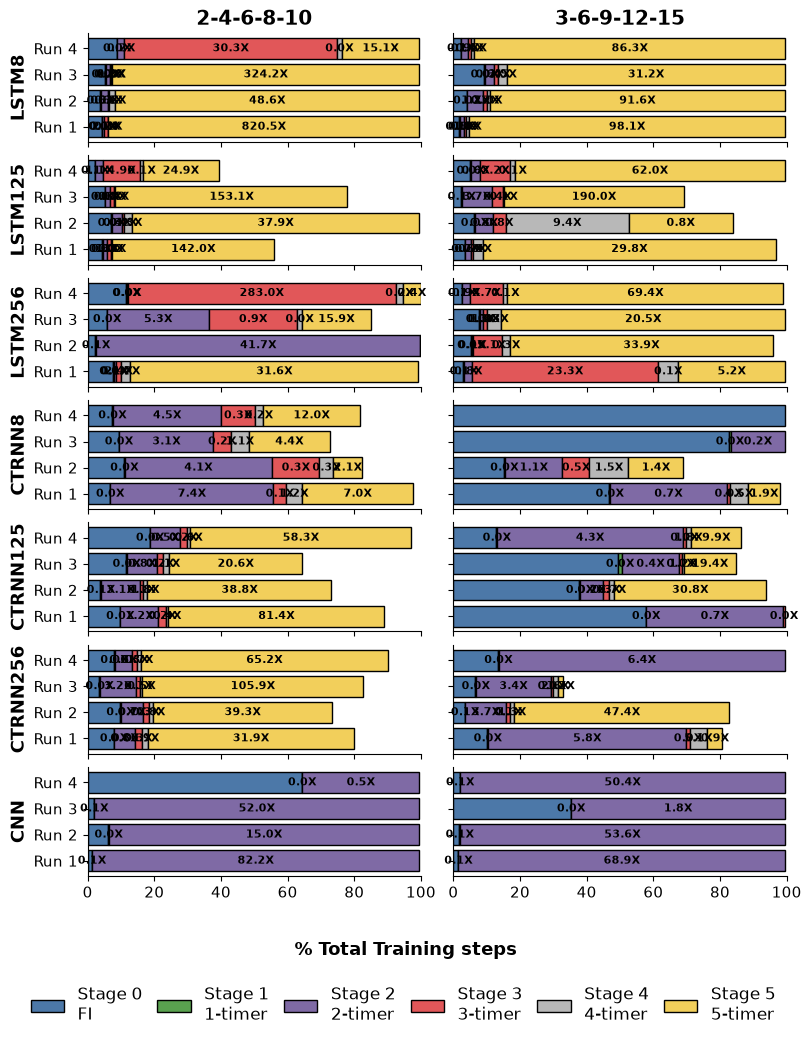

In [23]:

results = {
    "LSTM8": min_training_timesteps8,
    "LSTM125": min_training_timesteps125,
    "LSTM256": min_training_timesteps256,
    "CTRNN8": min_training_timesteps_ctrnn8,
    "CTRNN125": min_training_timesteps_ctrnn125,
    "CTRNN256": min_training_timesteps_ctrnn256,
    "CNN": min_training_timesteps_cnn
}
training_timesteps_rows = []
colors = [
    "#4C78A8", "#59A14F",  "#7F6AA5",
    "#E15759", "#B8B8B8",
    "#F2CF5B",
]
models = list(results.keys())
# anchors = list(results[models[0]].keys())
td_list = ['2-4-6-8-10','3-6-9-12-15']
max_training_ts = 1760000  # <-- total training timesteps

fig, axes = plt.subplots(
    len(models),          # rows
    len(td_list),         # columns
    figsize=(8,9
            ),
    squeeze=False,
    sharex=True,
    constrained_layout=True
)

for row, model in enumerate(models):

    for col, anchor in enumerate(td_list):

        ax = axes[row, col]

        runs = sorted(results[model][anchor].keys())
        y = np.arange(len(runs))

        left = np.zeros(len(runs))
        values_stages = {
                0: [],
                1: [],
                2: [],
                3: [],
                4: [],
                5: []
            } 
    
        perc_increase_stages = {
                0: [],
                1: [],
                2: [],
                3: [],
                4: [],
                5: []
            } 

        for stage in range(6):

            widths = []
            perc_increase= []

            for run in runs:

                values = np.array(results[model][anchor][run])

                values_stages[stage].append(values[stage])
                    
                learning_time = np.diff(
                    np.insert(values, 0, 0)
                ).astype(float)
                
                learning_time = [lt if lt>0 else np.nan for lt in learning_time]
                

                if stage >= len(learning_time):
                    widths.append(0)
                    continue

                # if learning_time[stage] <= 0:
                #     learning_time[stage] = np.nan

                # Convert stage duration to percentage of total training
                widths.append(100 * learning_time[stage] / max_training_ts)

                if stage ==2:
                    perc_increase.append( learning_time[stage] / learning_time[stage-2])
                elif stage > 0:
                    perc_increase.append( learning_time[stage] / learning_time[stage-1])
                else:
                    perc_increase.append(np.nan)

            if stage > 0:
                perc_increase_stages[stage] = perc_increase
            else:
                perc_increase_stages[stage] = widths # significance test - for stage one instead of xtimes previous stage, get % timesteps needed for stage 1 
   

            if stage == 0:
                leg_label = f"Stage {stage} \nFI"
            else:
                leg_label = f"Stage {stage} \n{stage}-timer" 
            ax.barh(
                y,
                widths,
                left=left,
                color=colors[stage],
                edgecolor="black",
                linewidth=1,
                label=leg_label if (row == 0 and col == 0) else None,
            )

            for run_idx, (width, perc) in enumerate(
                zip(widths, perc_increase)
            ):

                if (
                    np.isnan(perc)
                    or width <= 0
                ):
                    continue

                # Center of this bar segment
                x_text = (
                    left[run_idx]
                    + width / 2
                )

                ax.text(
                    x_text,
                    y[run_idx],
                    f"{perc:.1f}X",
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color="black"
                )



            left += np.nan_to_num(widths)

        ax.set_yticks(y)

        if col == 0:
            ax.set_yticklabels([f"Run {r}" for r in runs])
            ax.set_ylabel(model, fontweight="bold")
        else:
            ax.set_yticklabels([])

        if row == 0:
            ax.set_title(anchor, fontweight="bold")

        # if row == len(models) - 1:
        #     ax.set_xlabel("% Total Training")

        ax.set_xlim(0, 100)
        for run in range(len(runs)):
            if "CTRNN" in model:
                arch = "CTRNN"
                mem_size = int(model[5:])
            elif "LSTM" in model:
                arch = "LSTM"
                mem_size = int(model[4:])
            else:
                arch="CNN"
                mem_size=-1
            training_timesteps_rows.append({"architecture":arch, "memory_size":mem_size, "model":model,"anchor":anchor, "run":run, 
                                           "stage0":values_stages[0][run], "stage1":values_stages[1][run], "stage2":values_stages[2][run],
                                            "stage3":values_stages[3][run], "stage4":values_stages[4][run], "stage5":values_stages[5][run],
                                           "stage0_pct": perc_increase_stages[0][run], "stage1-0":perc_increase_stages[1][run], 
                                            "stage2-1":perc_increase_stages[2][run], "stage3-2":perc_increase_stages[3][run],
                                            "stage4-3":perc_increase_stages[4][run], "stage5-4":perc_increase_stages[5][run]})

        # ax.grid(axis="x", alpha=0.3)

# axes[0, 0].legend(title="Curriculum stage", ncols=3, loc="lower center", )
fig.supxlabel("% Total Training steps", y =-0.06, fontsize=13, fontweight="bold")
# plt.tight_layout()
handles, labels_ = axes[0, 0].get_legend_handles_labels()

leg = fig.legend(
    handles,
    labels_ ,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(labels_),
    # ncol=2,
    frameon=False,
    columnspacing=0.6
)

plt.savefig("multitimer_scalability_cat_supp.pdf", bbox_inches='tight')
        
plt.show()
training_timestep_df = pd.DataFrame(training_timesteps_rows)

# significant effect - architecture, memory size, anchor conf 

In [24]:

# significance test to check effect of env config, architecture, memory size, their interaction 
def overall_significance_test(training_timestep_df, colname, model_str=None ):
    anova_results = []

    df = training_timestep_df[["architecture","memory_size", "anchor", "run", colname]].dropna()
    # Make categorical variables explicit
    df["architecture"] = df["architecture"].astype("category")
    df["memory_size"] = df["memory_size"].astype("category")
    df["anchor"] = df["anchor"].astype("category")
    df = df.rename(columns={colname:"performance"})
    

    if model_str:
        model = smf.ols(model_str, data=df).fit()
    else:
        model = smf.ols(
        "performance ~ C(architecture)*C(memory_size) + C(anchor)",
        data=df).fit()

    stat, p = shapiro(model.resid)
    print("Shapiro-Wilk:", stat, p)
    print("architecture effect",df.groupby("architecture")["performance"].agg(["count","mean", "std","median"]))
    print("anchor effect",df.groupby("anchor")["performance"].agg(["count","mean", "std","median"]))

    df["residual"] = model.resid
    res_125 = df[df["memory_size"] == 125]["residual"]
    res_256 = df[df["memory_size"] == 256]["residual"]
    
    stat, p = levene(res_125, res_256, center="median")
    
    print(f"Levene: W={stat:.3f}, p={p:.3f}")

    if p < 0.05:
        print("unequal variance so using cov_type=HC3")
        if model_str:
            model = smf.ols(model_str, data=df).fit(cov_type="HC3")
            
        else:            
            model = smf.ols(
                "performance ~ C(architecture) + C(memory_size) + C(anchor)",
                data=df
            ).fit(cov_type="HC3")

       
    # print(sm.stats.anova_lm(model, typ=2))
    anova = sm.stats.anova_lm(model, typ=2)
    # print(model.t_test("C(memory_size)[T.256]"))
    print(anova)
    anova_results.append(anova)
    return anova_results        

def archlevel_significance_test(training_timestep_df, colname ):
    anova_results = []
    for arch in ["LSTM", "CTRNN"]:
        print("")
        print(arch)
        df = training_timestep_df[["architecture","memory_size", "anchor", "run", colname]].dropna()
        df = df[df["architecture"] == arch].copy()
        # Make categorical variables explicit
        df["architecture"] = df["architecture"].astype("category")
        df["memory_size"] = df["memory_size"].astype("category")
        df["anchor"] = df["anchor"].astype("category")
        df = df.rename(columns={colname:"performance"})
        
    
        model = smf.ols(
            "performance ~ C(memory_size) + C(anchor)",
            data=df
        ).fit()
    
        stat, p = shapiro(model.resid)
        print("Shapiro-Wilk:", stat, p)
        print("memory effect",df.groupby("memory_size")["performance"].agg(["count","mean", "std","median"]))
        print("anchor effect",df.groupby("anchor")["performance"].agg(["count","mean", "std","median"]))
    
        df["residual"] = model.resid
        res_8 = df[df["memory_size"] == 8]["residual"]
        res_125 = df[df["memory_size"] == 125]["residual"]
        res_256 = df[df["memory_size"] == 256]["residual"]
        
        stat, p = levene(res_8, res_125, res_256, center="median")
        
        print(f"Levene: W={stat:.3f}, p={p:.3f}")
    
        if p < 0.05:
            print("unequal variance so using cov_type=HC3")
            model = smf.ols(
            "performance ~ C(memory_size) + C(anchor)",
                data=df
            ).fit(cov_type="HC3")
           
        # print(sm.stats.anova_lm(model, typ=2))
        anova = sm.stats.anova_lm(model, typ=2)
        # print(model.t_test("C(memory_size)[T.256]"))
        print(anova)
        anova_results.append(anova)
    return anova_results
    


In [84]:
# # if normality is violated in the above old tests and anchor does not have significant effect in the overall test with n>25 
# # use the following test to justify combining models within architecture 
# def memory_within_arch(training_timestep_df, colname):

#     # anova_results = []
#     for arch in ["LSTM", "CTRNN"]:
#         print("")
#         print(arch)
#         df = training_timestep_df[["architecture","memory_size", "anchor", "run", colname]].dropna()
#         df = df[df["architecture"] == arch].copy()
#         x1 = df[df["memory_size"]==125][colname]
#         n_x = len(x1)
#         y1 = df[df["memory_size"]==256][colname]
#         n_y = len(y1)
#         print(n_x,n_y)
#         # get 
        

#             # --- Normality check ---
#         sh_x_p = shapiro(x1)[1] if n_x >= 3 else np.nan
#         sh_y_p = shapiro(y1)[1] if n_y >= 3 else np.nan
#         normal = (not np.isnan(sh_x_p)) and (not np.isnan(sh_y_p)) and (sh_x_p > 0.05) and (sh_y_p > 0.05)
    
#         # --- Homogeneity of variance check ---
#         lev_p = levene(x1, y1)[1] if n_x >= 2 and n_y >= 2 else np.nan
#         equal_var = (not np.isnan(lev_p)) and (lev_p > 0.05)
    
#         if normal:
#             stat, p = ttest_ind(x1, y1, equal_var=equal_var)
#             test_used = "Welch's t-test" if not equal_var else "Student's t-test"
#         else:
#             # Fallback: Mann-Whitney U test (non-parametric, no normality assumption)
#             try:
#                 stat, p = mannwhitneyu(x1, y1, alternative="two-sided")
#                 test_used = "Mann-Whitney U"
#             except ValueError:
#                 stat, p = np.nan, np.nan
#                 test_used = "Mann-Whitney U (failed, insufficient data)"

#         print(test_used, "normality", normal, "equal variance", equal_var, stat, p)

In [25]:


def memory_within_arch_more_categories(training_timestep_df, colname):

    for arch in ["LSTM", "CTRNN"]:
        print("")
        print(arch)
        df = training_timestep_df[["architecture", "memory_size", "anchor", "run", colname]].dropna()
        df = df[df["architecture"] == arch].copy()

        memory_sizes = sorted(df["memory_size"].unique())
        groups = {m: df[df["memory_size"] == m][colname] for m in memory_sizes}

        for m, vals in groups.items():
            print(f"n({m}) = {len(vals)}")

        # --- Normality check (per group) ---
        normal_flags = {}
        for m, vals in groups.items():
            sh_p = shapiro(vals)[1] if len(vals) >= 3 else np.nan
            normal_flags[m] = (not np.isnan(sh_p)) and (sh_p > 0.05)
            print(f"Shapiro-Wilk {m}: p={sh_p:.4f}" if not np.isnan(sh_p) else f"Shapiro-Wilk {m}: insufficient data")

        all_normal = all(normal_flags.values())

        # --- Homogeneity of variance check (works for 2+ groups) ---
        valid_groups = [v for v in groups.values() if len(v) >= 2]
        if len(valid_groups) >= 2:
            lev_stat, lev_p = levene(*valid_groups)
            equal_var = lev_p > 0.05
        else:
            lev_p, equal_var = np.nan, False
        print(f"Levene: stat={lev_stat:.3f}, p={lev_p:.4f}, equal_var={equal_var}" if not np.isnan(lev_p) else "Levene: insufficient data")

        n_groups = len(memory_sizes)

        if n_groups == 2:
            m1, m2 = memory_sizes
            x1, y1 = groups[m1], groups[m2]
            if all_normal:
                stat, p = ttest_ind(x1, y1, equal_var=equal_var)
                test_used = "Welch's t-test" if not equal_var else "Student's t-test"
            else:
                try:
                    stat, p = mannwhitneyu(x1, y1, alternative="two-sided")
                    test_used = "Mann-Whitney U"
                except ValueError:
                    stat, p = np.nan, np.nan
                    test_used = "Mann-Whitney U (failed, insufficient data)"
            print(test_used, "normality:", all_normal, "equal_var:", equal_var, "stat:", stat, "p:", p)

        elif n_groups > 2:
            group_vals = list(groups.values())
            if all_normal:
                stat, p = f_oneway(*group_vals)
                test_used = "One-way ANOVA"
            else:
                stat, p = kruskal(*group_vals)
                test_used = "Kruskal-Wallis"
            print(test_used, "normality:", all_normal, "equal_var:", equal_var, "stat:", stat, "p:", p)

            # --- Post-hoc pairwise comparisons if omnibus test is significant ---
            if p < 0.05:
                print("  Post-hoc pairwise comparisons (Holm-corrected):")
                pairs = list(combinations(memory_sizes, 2))
                pvals = []
                for m1, m2 in pairs:
                    x, y = groups[m1], groups[m2]
                    if all_normal:
                        _, p_pair = ttest_ind(x, y, equal_var=equal_var)
                    else:
                        _, p_pair = mannwhitneyu(x, y, alternative="two-sided")
                    pvals.append(p_pair)
                reject, pvals_corr, _, _ = multipletests(pvals, method="holm")
                for (m1, m2), p_raw, p_corr, rej in zip(pairs, pvals, pvals_corr, reject):
                    print(f"    {m1} vs {m2}: p_raw={p_raw:.4f}, p_holm={p_corr:.4f}, significant={rej}")
        else:
            print("Not enough groups to compare.")

In [26]:
def architecture_level_independent_test(significance_test_df, colname, first_arch=None):
    lstm, ctrnn = None, None
    for grp, data in significance_test_df.groupby("architecture"):
        if grp == "CTRNN":
            ctrnn = data[colname].dropna()
        if grp == "LSTM":
            lstm = data[colname].dropna()
    
    if first_arch == "ctrnn":
        arch_comparison_ordered = [ctrnn,lstm]
    elif first_arch == "lstm":
        arch_comparison_ordered = [lstm,ctrnn]
    else:
        raise ValueError("no arch order specified. provide an arch order for alternative = greater test")

        
    # --- Normality check (per group) ---
    sh_lstm_p = shapiro(lstm)[1] if len(lstm) >= 3 else np.nan
    sh_ctrnn_p = shapiro(ctrnn)[1] if len(ctrnn) >= 3 else np.nan
    normal = (not np.isnan(sh_lstm_p)) and (not np.isnan(sh_ctrnn_p)) and (sh_lstm_p > 0.05) and (sh_ctrnn_p > 0.05)
    print(f"Shapiro-Wilk: LSTM p={sh_lstm_p:.4f}, CTRNN p={sh_ctrnn_p:.4f}, normal={normal}")
    
    # --- Homogeneity of variance check ---
    lev_stat, lev_p = levene(lstm, ctrnn, center="median")
    equal_var = lev_p > 0.05
    print(f"Levene: stat={lev_stat:.3f}, p={lev_p:.4f}, equal_var={equal_var}")
    
    # --- Choose test based on assumptions ---
    if normal:
        t, p = ttest_ind(ctrnn, lstm, equal_var=equal_var, alternative="greater")
        test_used = "Welch's t-test" if not equal_var else "Student's t-test"
    else:
        # Fallback: Mann-Whitney U (non-parametric, independent samples)
        t, p = mannwhitneyu(ctrnn, lstm, alternative="greater")
        test_used = "Mann-Whitney U"
    
    print(f"Test used: {test_used}, stat={t:.3f}, p={p:.4f}")

In [27]:
# test if cl_ratio per model or architecture is more than 1x 
def cl_ratio_vs_1x(vals, alternative="greater"):
    vals = vals.dropna()
    n = len(vals)
    sh_p = shapiro(vals)[1] if n >= 3 else np.nan
    normal = (not np.isnan(sh_p)) and (sh_p > 0.05)

    if normal:
        stat, p = ttest_1samp(vals, popmean=1, alternative=alternative)
        test_used = "t-test"
    else:
        try:
            stat, p = wilcoxon(vals - 1, alternative=alternative)
            test_used = "Wilcoxon"
        except ValueError:
            stat, p = np.nan, np.nan
            test_used = "Wilcoxon (failed, likely all-zero diffs)"

    return n, sh_p, normal, test_used, stat, p

# CL stage 0 

In [76]:
training_timestep_df

,architecture,memory_size,model,anchor,run,stage0,stage1,stage2,stage3,stage4,stage5,stage0_pct,stage1-0,stage2-1,stage3-2,stage4-3,stage5-4
0,LSTM,8,LSTM8,2-4-6-8-10,0,76000,78000,87000,107000,109000,1750000,4.318182,0.026316,0.118421,2.222222,0.100000,820.500000
1,LSTM,8,LSTM8,2-4-6-8-10,1,67000,70000,107000,112000,145000,1750000,3.806818,0.044776,0.552239,0.135135,6.600000,48.636364
2,LSTM,8,LSTM8,2-4-6-8-10,2,93000,96000,119000,124000,129000,1750000,5.284091,0.032258,0.247312,0.217391,1.000000,324.200000
3,LSTM,8,LSTM8,2-4-6-8-10,3,153000,157000,194000,1315000,1342000,1750000,8.693182,0.026144,0.241830,30.297297,0.024086,15.111111
4,LSTM,8,LSTM8,3-6-9-12-15,0,31000,33000,57000,66000,83000,1750000,1.761364,0.064516,0.774194,0.375000,1.888889,98.058824
5,LSTM,8,LSTM8,3-6-9-12-15,1,71000,74000,158000,175000,192000,1750000,4.034091,0.042254,1.183099,0.202381,1.000000,91.647059
6,LSTM,8,LSTM8,3-6-9-12-15,2,164000,166000,217000,236000,283000,1750000,9.318182,0.012195,0.310976,0.372549,2.473684,31.212766
7,LSTM,8,LSTM8,3-6-9-12-15,3,39000,42000,79000,92000,111000,1750000,2.215909,0.076923,0.948718,0.351351,1.461538,86.263158
8,LSTM,125,LSTM125,2-4-6-8-10,0,78000,81000,103000,125000,131000,983000,4.431818,0.038462,0.282051,1.000000,0.272727,142.000000
9,LSTM,125,LSTM125,2-4-6-8-10,1,125000,129000,181000,193000,233000,1750000,7.102273,0.032000,0.416000,0.230769,3.333333,37.925000


In [95]:
# filter cases of non-convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage0"] < 1750000) & (training_timestep_df["stage0"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
colname = "stage0_pct"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

----------------------------------------------------------------------
Total convergence                           count       mean        std     median
architecture memory_size                                        
CTRNN        8                7  25.487013  28.841834  10.852273
             125              8  25.191761  20.296488  15.738636
             256              8   7.791193   3.383895   7.840909
LSTM         8                8   4.928977   2.761679   4.176136
             125              8   4.488636   1.770634   4.744318
             256              8   5.703125   3.207362   5.454545
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.8708807771501438 9.594107535112391e-05
architecture effect               count       mean        std     median
architecture                                        
CTRNN            23  19.229249  20.845817  10.170455
LSTM             

In [97]:
# is ctrnn significantly greater than lstm 

# filter for convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage0"] < 1750000) & (training_timestep_df["stage0"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
colname = "stage0_pct"


architecture_level_independent_test(significance_test_df, colname, first_arch="ctrnn")

Shapiro-Wilk: LSTM p=0.1102, CTRNN p=0.0000, normal=False
Levene: stat=6.833, p=0.0121, equal_var=False
Test used: Mann-Whitney U, stat=473.000, p=0.0000


# stage 1-0

In [98]:
# filter cases of non-convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage1"] < 1750000) & (training_timestep_df["stage1"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
colname = "stage1-0"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

----------------------------------------------------------------------
Total convergence                           count      mean       std    median
architecture memory_size                                     
CTRNN        8                7  0.020560  0.011273  0.020942
             125              8  0.018371  0.017521  0.013961
             256              8  0.029254  0.016468  0.024104
LSTM         8                8  0.040673  0.021384  0.037256
             125              8  0.051733  0.026064  0.041703
             256              8  0.059596  0.044574  0.041739
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.910109262175341 0.0015383000794992171
architecture effect               count      mean       std    median
architecture                                     
CTRNN            23  0.022823  0.015572  0.019518
LSTM             24  0.050667  0.031835  0.041127
a

In [99]:
# normality violoted - but anchor no significant effect in overall analysis with n>25
significance_test_df = training_timestep_df[(training_timestep_df["stage1"] < 1750000) & (training_timestep_df["stage1"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
colname = "stage1-0"
memory_within_arch_more_categories(significance_test_df, colname)


LSTM
n(8) = 8
n(125) = 8
n(256) = 8
Shapiro-Wilk 8: p=0.6955
Shapiro-Wilk 125: p=0.0148
Shapiro-Wilk 256: p=0.0694
Levene: stat=1.676, p=0.2111, equal_var=True
Kruskal-Wallis normality: False equal_var: True stat: 0.8149999999999977 p: 0.6653114513980292

CTRNN
n(8) = 7
n(125) = 8
n(256) = 8
Shapiro-Wilk 8: p=0.6340
Shapiro-Wilk 125: p=0.0029
Shapiro-Wilk 256: p=0.0037
Levene: stat=0.009, p=0.9908, equal_var=True
Kruskal-Wallis normality: False equal_var: True stat: 4.454580745341616 p: 0.10782018720671381


In [100]:
# is lstm significantly greater than ctrnn 

# filter for convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage1"] < 1750000) & (training_timestep_df["stage1"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
colname = "stage1-0"


architecture_level_independent_test(significance_test_df, colname, first_arch="lstm")

Shapiro-Wilk: LSTM p=0.0041, CTRNN p=0.0029, normal=False
Levene: stat=4.891, p=0.0321, equal_var=False
Test used: Mann-Whitney U, stat=95.000, p=0.9999


In [56]:

# architecture level analysis across memory size and anchors - 
#  mention the results with caveats of signifcant effect of memory or anchor or interaction terms in case any 


# Is CL-efficiency ratio >1x ?
alternative="less"

# filter for convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage1"] < 1750000) & (training_timestep_df["stage1"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
colname = "stage1-0"

# --- Architecture-level (primary result, given memory sizes pooled) ---
print("=== Architecture level ===")
for grp, data in significance_test_df.groupby("architecture"):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname],alternative=alternative)
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

# --- Per-model (optional, supplementary) ---
print("\n=== Per architecture-memory_size (supplementary) ===")
for grp, data in significance_test_df.groupby(["architecture", "memory_size"]):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

=== Architecture level ===
CTRNN: n=23, shapiro_p=0.003, normal=False, test=Wilcoxon, stat=0.000, p=0.0000
LSTM: n=24, shapiro_p=0.004, normal=False, test=Wilcoxon, stat=0.000, p=0.0000

=== Per architecture-memory_size (supplementary) ===
('CTRNN', 8): n=7, shapiro_p=0.634, normal=True, test=t-test, stat=-229.865, p=1.0000
('CTRNN', 125): n=8, shapiro_p=0.003, normal=False, test=Wilcoxon, stat=0.000, p=1.0000
('CTRNN', 256): n=8, shapiro_p=0.004, normal=False, test=Wilcoxon, stat=0.000, p=1.0000
('LSTM', 8): n=8, shapiro_p=0.695, normal=True, test=t-test, stat=-126.889, p=1.0000
('LSTM', 125): n=8, shapiro_p=0.015, normal=False, test=Wilcoxon, stat=0.000, p=1.0000
('LSTM', 256): n=8, shapiro_p=0.069, normal=True, test=t-test, stat=-59.674, p=1.0000


In [54]:
significance_test_df

,architecture,memory_size,model,anchor,run,stage0,stage1,stage2,stage3,stage4,stage5,stage0_pct,stage1-0,stage2-1,stage3-2,stage4-3,stage5-4
0,LSTM,8,LSTM8,2-4-6-8-10,0,76000,78000,87000,107000,109000,1750000,4.318182,0.026316,0.118421,2.222222,0.100000,820.500000
1,LSTM,8,LSTM8,2-4-6-8-10,1,67000,70000,107000,112000,145000,1750000,3.806818,0.044776,0.552239,0.135135,6.600000,48.636364
2,LSTM,8,LSTM8,2-4-6-8-10,2,93000,96000,119000,124000,129000,1750000,5.284091,0.032258,0.247312,0.217391,1.000000,324.200000
3,LSTM,8,LSTM8,2-4-6-8-10,3,153000,157000,194000,1315000,1342000,1750000,8.693182,0.026144,0.241830,30.297297,0.024086,15.111111
4,LSTM,8,LSTM8,3-6-9-12-15,0,31000,33000,57000,66000,83000,1750000,1.761364,0.064516,0.774194,0.375000,1.888889,98.058824
5,LSTM,8,LSTM8,3-6-9-12-15,1,71000,74000,158000,175000,192000,1750000,4.034091,0.042254,1.183099,0.202381,1.000000,91.647059
6,LSTM,8,LSTM8,3-6-9-12-15,2,164000,166000,217000,236000,283000,1750000,9.318182,0.012195,0.310976,0.372549,2.473684,31.212766
7,LSTM,8,LSTM8,3-6-9-12-15,3,39000,42000,79000,92000,111000,1750000,2.215909,0.076923,0.948718,0.351351,1.461538,86.263158
8,LSTM,125,LSTM125,2-4-6-8-10,0,78000,81000,103000,125000,131000,983000,4.431818,0.038462,0.282051,1.000000,0.272727,142.000000
9,LSTM,125,LSTM125,2-4-6-8-10,1,125000,129000,181000,193000,233000,1750000,7.102273,0.032000,0.416000,0.230769,3.333333,37.925000


# stage 2-1

In [67]:
# filter cases of non-convergence 
stage = 2
colname = f"stage{stage}-{stage-1}"
significance_test_df = training_timestep_df[(training_timestep_df[f"stage{stage}"] < 1750000) & (training_timestep_df[f"stage{stage}"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]

print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

----------------------------------------------------------------------
Total convergence                           count      mean       std    median
architecture memory_size                                     
CTRNN        8                6  3.485619  2.443411  3.564257
             125              8  1.384448  1.498724  0.744878
             256              7  2.601444  1.974688  3.180328
LSTM         8                8  0.547098  0.385444  0.431607
             125              8  0.963523  1.153496  0.534997
             256              7  1.052249  1.929447  0.123188
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.9012677780345066 0.0011906153213872706
architecture effect               count      mean       std    median
architecture                                     
CTRNN            21  2.390448  2.056395  1.182353
LSTM             23  0.845683  1.239748  0.508197


In [64]:
# normality violoted - but anchor no significant effect in overall analysis with n>25
# significance_test_df = training_timestep_df[(training_timestep_df["stage2"] < 1750000) & (training_timestep_df["stage2"] >0)].copy()
# significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
# colname = "stage2-1"
memory_within_arch_more_categories(significance_test_df, colname)


LSTM
n(8) = 8
n(125) = 8
n(256) = 7
Shapiro-Wilk 8: p=0.3655
Shapiro-Wilk 125: p=0.0003
Shapiro-Wilk 256: p=0.0003
Levene: stat=0.543, p=0.5893, equal_var=True
Kruskal-Wallis normality: False equal_var: True stat: 1.583074534161483 p: 0.4531476506048745

CTRNN
n(8) = 6
n(125) = 8
n(256) = 7
Shapiro-Wilk 8: p=0.6865
Shapiro-Wilk 125: p=0.0169
Shapiro-Wilk 256: p=0.1820
Levene: stat=0.843, p=0.4469, equal_var=True
Kruskal-Wallis normality: False equal_var: True stat: 4.059987631416206 p: 0.1313363333682038


In [68]:
# is ctrnn/lstm significantly greater than lstm/ctrnn


architecture_level_independent_test(significance_test_df, colname, first_arch="lstm")

Shapiro-Wilk: LSTM p=0.0000, CTRNN p=0.0090, normal=False
Levene: stat=6.714, p=0.0131, equal_var=False
Test used: Mann-Whitney U, stat=369.000, p=0.0014


In [62]:

# --- Architecture-level (primary result, given memory sizes pooled) ---
print("=== Architecture level ===")
for grp, data in significance_test_df.groupby("architecture"):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

# --- Per-model (optional, supplementary) ---
print("\n=== Per architecture-memory_size (supplementary) ===")
for grp, data in significance_test_df.groupby(["architecture", "memory_size"]):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

=== Architecture level ===
CTRNN: n=20, shapiro_p=0.000, normal=False, test=Wilcoxon, stat=123.000, p=0.2608
LSTM: n=23, shapiro_p=0.000, normal=False, test=Wilcoxon, stat=124.000, p=0.3838

=== Per architecture-memory_size (supplementary) ===
('CTRNN', 8): n=6, shapiro_p=0.028, normal=False, test=Wilcoxon, stat=12.000, p=0.4219
('CTRNN', 125): n=7, shapiro_p=0.417, normal=True, test=t-test, stat=0.369, p=0.3624
('CTRNN', 256): n=7, shapiro_p=0.013, normal=False, test=Wilcoxon, stat=17.000, p=0.3438
('LSTM', 8): n=8, shapiro_p=0.017, normal=False, test=Wilcoxon, stat=14.000, p=0.2812
('LSTM', 125): n=8, shapiro_p=0.005, normal=False, test=Wilcoxon, stat=21.000, p=0.3711
('LSTM', 256): n=7, shapiro_p=0.003, normal=False, test=Wilcoxon, stat=8.000, p=0.8516


# 5-timer n-capacity

In [69]:
significance_test_df = training_timestep_df[(training_timestep_df["stage5"] < 1750000) & (training_timestep_df["stage5"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
colname = "stage5-4"
print("----------------------------------------------------------------------")
print("Total convergence", significance_test_df.groupby(["architecture","memory_size"])[colname].agg(["count","mean","std","median"]))
print("----------------------------------------------------------------------")
print("--------------------------OVERALL-----------------------------------")

anova_overall_results_cl_stage0  =overall_significance_test(significance_test_df, colname, model_str=None )
print("----------------------------------------------------------------------")
print("-------------------------------WITHIN AN ARCHITECTURE---------------------")
anova_arch_results_cl_stage0  = archlevel_significance_test(significance_test_df, colname )

----------------------------------------------------------------------
Total convergence                           count       mean        std     median
architecture memory_size                                        
CTRNN        8                6   4.790807   4.079852   3.265054
             125              7  37.032985  25.111385  30.769231
             256              7  41.674448  36.771237  39.291667
LSTM         125              6  90.116146  80.617236  85.894231
             256              4  37.705068  22.605852  32.739329
----------------------------------------------------------------------
--------------------------OVERALL-----------------------------------
Shapiro-Wilk: 0.9579024508075654 0.27353060352986974
architecture effect               count       mean        std     median
architecture                                        
CTRNN            20  28.984844  29.975567  20.002101
LSTM             10  69.151715  67.182486  32.739329
anchor effect              coun

/tmp/ipykernel_146/889576900.py:18: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  data=df).fit()
/tmp/ipykernel_146/889576900.py:81: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = levene(res_8, res_125, res_256, center="median")


In [70]:
# is lstm significantly greater than ctrnn 

# filter for convergence 
significance_test_df = training_timestep_df[(training_timestep_df["stage5"] < 1750000) & (training_timestep_df["stage5"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
colname = "stage5-4"


architecture_level_independent_test(significance_test_df, colname, first_arch="lstm")

Shapiro-Wilk: LSTM p=0.0342, CTRNN p=0.0094, normal=False
Levene: stat=3.169, p=0.0859, equal_var=True
Test used: Mann-Whitney U, stat=66.000, p=0.9355


In [113]:
significance_test_df = training_timestep_df[(training_timestep_df["stage5"] < 1750000) & (training_timestep_df["stage5"] >0)].copy()
significance_test_df = significance_test_df[significance_test_df["architecture"]!="CNN"]
colname = "stage5-4"

# --- Architecture-level (primary result, given memory sizes pooled) ---
print("=== Architecture level ===")
for grp, data in significance_test_df.groupby("architecture"):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

# --- Per-model (optional, supplementary) ---
print("\n=== Per architecture-memory_size (supplementary) ===")
for grp, data in significance_test_df.groupby(["architecture", "memory_size"]):
    n, sh_p, normal, test_used, stat, p = cl_ratio_vs_1x(data[colname])
    print(f"{grp}: n={n}, shapiro_p={sh_p:.3f}, normal={normal}, "
          f"test={test_used}, stat={stat:.3f}, p={p:.4f}")

=== Architecture level ===
CTRNN: n=20, shapiro_p=0.009, normal=False, test=Wilcoxon, stat=209.000, p=0.0000
LSTM: n=10, shapiro_p=0.034, normal=False, test=Wilcoxon, stat=54.000, p=0.0020

=== Per architecture-memory_size (supplementary) ===
('CTRNN', 8): n=6, shapiro_p=0.155, normal=True, test=t-test, stat=2.276, p=0.0360
('CTRNN', 125): n=7, shapiro_p=0.457, normal=True, test=t-test, stat=3.796, p=0.0045
('CTRNN', 256): n=7, shapiro_p=0.577, normal=True, test=t-test, stat=2.927, p=0.0132
('LSTM', 125): n=6, shapiro_p=0.201, normal=True, test=t-test, stat=2.708, p=0.0212
('LSTM', 256): n=4, shapiro_p=0.432, normal=True, test=t-test, stat=3.247, p=0.0238


# combine models within architectures ?

In [60]:
stage3-2 - first introduction of multi timer - ctrnn architectures more than lstm (check with significance test)
stage4-3 - ctrnn in genral lower than lstm 
stage5-4 - ctrnnn lower 
stage6-5

SyntaxError: invalid syntax (2577447625.py, line 1)

In [28]:
colname = "stage2-1"
# colname="stage0"

significance_test_stage1_0_df = training_timestep_df[["model", "anchor", "run", colname]].dropna()



for arch in ["LSTM", "CTRNN"]:
   
    df = significance_test_stage1_0_df[significance_test_stage1_0_df["model"].str.contains(arch)]
    
    print(arch, len(df))

    # Make categorical variables explicit
    df["model"] = df["model"].astype("category")
    df = df.rename(columns={colname:"performance"})
    print(df.groupby(["model"])["performance"].mean())

    model = smf.ols(
        # "performance ~ C(memory_size) + C(anchor) + C(memory_size) * C(anchor)",
        "performance ~ C(model)",
        data=df
    ).fit()

    stat, p = shapiro(model.resid)
    print("Shapiro-Wilk:", stat, p)
    print("data size",df.groupby("model")["run"].count())

    df["residual"] = model.resid
    res_125 = df[df["model"].str.contains("125")]["residual"]
    res_256 = df[df["model"].str.contains("125")]["residual"]
    
    stat, p = levene(res_125, res_256, center="median")
    
    print(f"Levene: W={stat:.3f}, p={p:.3f}")
       
    # print(sm.stats.anova_lm(model, typ=2))
    anova = sm.stats.anova_lm(model, typ=2)
    # print(model.t_test("C(memory_size)[T.256]"))
    print(anova)
    

# # filtered_avg_bp_jnd_wf_df_all.groupby(["model"])[["bp"]].describe()    


LSTM 12
model
LSTM125    0.055878
LSTM256    0.049779
LSTM8      0.032373
Name: performance, dtype: float64
Shapiro-Wilk: 0.8372585914259214 0.02564617635375422
data size model
LSTM125    4
LSTM256    4
LSTM8      4
Name: run, dtype: int64
Levene: W=0.000, p=1.000
           sum_sq   df        F    PR(>F)
C(model)  0.00119  2.0  0.47692  0.635526
Residual  0.01123  9.0      NaN       NaN
CTRNN 12
model
CTRNN125    0.026072
CTRNN256    0.025251
CTRNN8      0.026270
Name: performance, dtype: float64
Shapiro-Wilk: 0.8405097023806294 0.028085456392121462
data size model
CTRNN125    4
CTRNN256    4
CTRNN8      4
Name: run, dtype: int64
Levene: W=0.000, p=1.000
            sum_sq   df         F    PR(>F)
C(model)  0.000002  2.0  0.005691  0.994329
Residual  0.001845  9.0       NaN       NaN


# comapre architectures for CL stage increase 

# stage 0 - learn soup delivery task with 1 timer - fi case

In [23]:
# stage 0 - learn soup delivery task with 1 timer - fi case
colname = "stage1-0"

significance_test_stage1_0_df = training_timestep_df[["architecture","memory_size", "model", "anchor", "run", colname]].dropna()
significance_test_stage1_0_df.groupby("architecture")[colname].describe()

,count,mean,std,min,25%,50%,75%,max
architecture,,,,,,,,
CTRNN,12.0,8.873106,3.952092,3.465909,7.102273,8.579545,10.000000,18.579545
LSTM,12.0,5.662879,2.706894,2.102273,4.190341,5.170455,7.230114,11.534091


In [27]:
# is ctrnn significantly different than lstm

for grp, data in significance_test_stage1_0_df.groupby("architecture"):
    if grp=="CTRNN":
        ctrnn = data[colname]
    if grp == "LSTM":
        lstm=data[colname]

x1=ctrnn
y1=lstm
n_x = len(ctrnn)
n_y = len(lstm)

# --- Normality check ---
sh_x_p = shapiro(x1)[1] if n_x >= 3 else np.nan
sh_y_p = shapiro(y1)[1] if n_y >= 3 else np.nan
normal = (not np.isnan(sh_x_p)) and (not np.isnan(sh_y_p)) and (sh_x_p > 0.05) and (sh_y_p > 0.05)

# --- Homogeneity of variance check ---
lev_p = levene(x1, y1)[1] if n_x >= 2 and n_y >= 2 else np.nan
equal_var = (not np.isnan(lev_p)) and (lev_p > 0.05)

if normal:
    stat, p = ttest_ind(x1, y1, equal_var=equal_var)
    test_used = "Welch's t-test" if not equal_var else "Student's t-test"
else:
    # Fallback: Mann-Whitney U test (non-parametric, no normality assumption)
    try:
        stat, p = mannwhitneyu(x1, y1, alternative="two-sided")
        test_used = "Mann-Whitney U"
    except ValueError:
        stat, p = np.nan, np.nan
        test_used = "Mann-Whitney U (failed, insufficient data)"
    
# stat, p = shapiro(model.resid)
# print("Shapiro-Wilk:", stat, p)
print("data size",len(lstm), len(ctrnn))

print("normal", normal)
# stat, p = levene(lstm, ctrnn, center="median")  
print("equal variance",equal_var, stat,p)

# t, p = ttest_ind(
#     ctrnn,
#     lstm,
# )
# t,p
stat, p, test_used

data size 12 12
normal True
equal variance True 2.3215069601387675 0.029914349318573938


(np.float64(2.3215069601387675),
 np.float64(0.029914349318573938),
 "Student's t-test")

# stage 2 - first introduction of multi-timer

In [123]:
colname = "stage3-2"

# training_timestep_df1 = training_timestep_df[(~training_timestep_df[colname].isna())  & (training_timestep_df[colname]<20)] # remove outliers 
significance_test_stage1_0_df = training_timestep_df[["architecture","memory_size", "model", "anchor", "run", colname]].dropna()
significance_test_stage1_0_df.groupby("architecture")[colname].describe()

,count,mean,std,min,25%,50%,75%,max
architecture,,,,,,,,
CTRNN,12.0,2.485733,2.132702,0.474006,0.755611,2.118784,3.403571,7.405172
LSTM,12.0,4.196149,11.888566,0.024631,0.210978,0.287093,0.684449,41.658537


In [124]:
# is ctrnn significantly different than lstm

for grp, data in significance_test_stage1_0_df.groupby("architecture"):
    t, p = ttest_1samp(data[colname], popmean=1, nan_policy="omit", alternative="greater")
    
    print(f"{grp} Ratio vs 1x: t = {t:.3f}, p = {p:.4f}", len(data))
    
    if grp=="CTRNN":
        ctrnn = data[colname]
    if grp == "LSTM":
        lstm=data[colname]
    
    
x1=ctrnn
y1=lstm
n_x = len(ctrnn)
n_y = len(lstm)

# --- Normality check ---
sh_x_p = shapiro(x1)[1] if n_x >= 3 else np.nan
sh_y_p = shapiro(y1)[1] if n_y >= 3 else np.nan
normal = (not np.isnan(sh_x_p)) and (not np.isnan(sh_y_p)) and (sh_x_p > 0.05) and (sh_y_p > 0.05)

# --- Homogeneity of variance check ---
lev_p = levene(x1, y1)[1] if n_x >= 2 and n_y >= 2 else np.nan
equal_var = (not np.isnan(lev_p)) and (lev_p > 0.05)

if normal:
    stat, p = ttest_ind(x1, y1, equal_var=equal_var)
    test_used = "Welch's t-test" if not equal_var else "Student's t-test"
else:
    # Fallback: Mann-Whitney U test (non-parametric, no normality assumption)
    try:
        stat, p = mannwhitneyu(x1, y1, alternative="two-sided")
        test_used = "Mann-Whitney U"
    except ValueError:
        stat, p = np.nan, np.nan
        test_used = "Mann-Whitney U (failed, insufficient data)"
    
# stat, p = shapiro(model.resid)
# print("Shapiro-Wilk:", stat, p)
print("data size",len(lstm), len(ctrnn))

print("normal", normal)
# stat, p = levene(lstm, ctrnn, center="median")  
print("equal variance",equal_var, stat,p)

# t, p = ttest_ind(
#     ctrnn,
#     lstm,
# )
# t,p
stat, p, test_used

CTRNN Ratio vs 1x: t = 2.413, p = 0.0172 12
LSTM Ratio vs 1x: t = 0.931, p = 0.1858 12
data size 12 12
equal variance 0.4487887420526578 0.5098818027466788


(np.float64(-0.4905517724890847), np.float64(0.6286006595488414))

# stage 3 - 3 timers 

In [121]:
colname = "stage4-3"

# training_timestep_df1 = training_timestep_df[(~training_timestep_df[colname].isna())  & (training_timestep_df[colname]<20)] # remove outliers 
significance_test_stage1_0_df = training_timestep_df[["architecture","memory_size", "model", "anchor", "run", colname]].dropna()
significance_test_stage1_0_df.groupby("architecture")[colname].describe()

,count,mean,std,min,25%,50%,75%,max
architecture,,,,,,,,
CTRNN,12.0,0.216527,0.096063,0.067961,0.16411,0.210656,0.307743,0.342593
LSTM,11.0,29.639862,84.486810,0.135135,0.50000,1.000000,3.645833,283.000000


In [122]:
# is ctrnn significantly different than lstm

for grp, data in significance_test_stage1_0_df.groupby("architecture"):
    t, p = ttest_1samp(data[colname], popmean=1, nan_policy="omit", alternative="greater")
    
    print(f"{grp} Ratio vs 1x: t = {t:.3f}, p = {p:.4f}", len(data))
    if grp=="CTRNN":
        ctrnn = data[colname]
    if grp == "LSTM":
        lstm=data[colname]
    
    
# stat, p = shapiro(model.resid)
# print("Shapiro-Wilk:", stat, p)
print("data size",len(lstm), len(ctrnn))


stat, p = levene(lstm, ctrnn, center="median")  
print("equal variance",stat,p)

t, p = ttest_ind(
    ctrnn,
    lstm,
)
t,p

CTRNN Ratio vs 1x: t = -28.253, p = 1.0000 12
LSTM Ratio vs 1x: t = 1.124, p = 0.1436 11
data size 11 12
equal variance 1.4326724626898053 0.24466679561154447


(np.float64(-1.2090252324844109), np.float64(0.24009005589423474))

# Stage 4

In [114]:
colname = "stage5-4"

# training_timestep_df1 = training_timestep_df[(~training_timestep_df[colname].isna())  & (training_timestep_df[colname]<20)] # remove outliers 
significance_test_stage1_0_df = training_timestep_df[["architecture","memory_size", "model", "anchor", "run", colname]].dropna()
significance_test_stage1_0_df.groupby("architecture")[colname].describe()

,count,mean,std,min,25%,50%,75%,max
architecture,,,,,,,,
CTRNN,12.0,0.797028,0.449253,0.244318,0.484962,0.744240,1.074542,1.785714
LSTM,11.0,1.231280,2.049122,0.024086,0.065598,0.272727,1.327586,6.600000


In [115]:
# is ctrnn significantly different than lstm

for grp, data in significance_test_stage1_0_df.groupby("architecture"):
    t, p = ttest_1samp(data[colname], popmean=1, nan_policy="omit", alternative="greater")
    
    print(f"{grp} Ratio vs 1x: t = {t:.3f}, p = {p:.4f}", len(data))
    if grp=="CTRNN":
        ctrnn = data[colname]
    if grp == "LSTM":
        lstm=data[colname]
    
    
# stat, p = shapiro(model.resid)
# print("Shapiro-Wilk:", stat, p)
print("data size",len(lstm), len(ctrnn))


stat, p = levene(lstm, ctrnn, center="median")  
print("equal variance",stat,p)

t, p = ttest_ind(
    ctrnn,
    lstm,
    alternative="greater"
)
t,p

CTRNN Ratio vs 1x: t = -1.565, p = 0.9271 12
LSTM Ratio vs 1x: t = 0.374, p = 0.3580 11
data size 11 12
equal variance 2.056271298711186 0.1663041496599353


(np.float64(-0.716999031805383), np.float64(0.7593629387446866))

# last stage - 

In [152]:
# how many runs of each architecture successfully finish 5 stages ? 100& in ctrnn and 41% in LSTM 
colname = "stage6-5"
training_timestep_df1 = training_timestep_df[(~training_timestep_df[colname].isna())  & (training_timestep_df["stage5"]<1750000)] # keep only cases that successfully finish 5 stages  
significance_test_stage1_0_df = training_timestep_df1[["architecture","memory_size", "model", "anchor", "run", colname]].dropna()
significance_test_stage1_0_df.groupby("architecture")[colname].describe()

,count,mean,std,min,25%,50%,75%,max
architecture,,,,,,,,
CTRNN,12.0,38.909511,33.078066,2.082192,10.703212,35.375882,60.0125,105.909091
LSTM,5.0,73.520109,67.934671,15.913043,24.937500,31.625000,142.0000,153.125000


In [153]:
# is ctrnn significantly different than lstm

for grp, data in significance_test_stage1_0_df.groupby("architecture"):
    t, p = ttest_1samp(data[colname], popmean=1, nan_policy="omit", alternative="greater")
    
    print(f"{grp} Ratio vs 1x: t = {t:.3f}, p = {p:.4f}", len(data))
    if grp=="CTRNN":
        ctrnn = data[colname]
    if grp == "LSTM":
        lstm=data[colname]
    
    
# stat, p = shapiro(model.resid)
# print("Shapiro-Wilk:", stat, p)
print("data size",len(lstm), len(ctrnn))


stat, p = levene(lstm, ctrnn, center="median")  
print("equal variance",stat,p)

t, p = ttest_ind(
    ctrnn,
    lstm,
    alternative="greater"
)
t,p

CTRNN Ratio vs 1x: t = 3.970, p = 0.0011 12
LSTM Ratio vs 1x: t = 2.387, p = 0.0377 5
data size 5 12
equal variance 1.7869216676313564 0.201224070868539


(np.float64(-1.4420584997059684), np.float64(0.9150803297599382))

In [25]:
%load_ext tensorboard

In [22]:
!pip install -U tensorboard setuptools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 75.5 MB/s  0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0


In [28]:
tb_event_file = event_files125['2-4-6-8-10'][3]
%tensorboard --logdir $tb_event_file

In [31]:
tb_event_file = event_files_ctrnn125['2-4-6-8-10'][3]
%tensorboard --logdir $tb_event_file

In [7]:
# # numtimers 1 - evn0, 2, , 3-env1, 4-env2, 5-env3, 6-env4, 7-env5
# numtimers_envlabels = {1:0,2:0,3:1,4:2,5:3,6:4,7:5}
# oven_duration_list = [4,10,15,20,25]
# duration_list_id = "-".join(map(str, oven_duration_list))
# lstm_size = 125
# ent_coeff = 0
# timestep = 200
# g=0.99
# rows = []
# rows_traj = []
# overcooked_buffer =2
# models_folder = "/project_ghent/chronocooked/singleagent/train/multitimer_cl_tp_modelsv1"
# # for target_duration in oven_duration_list:
# for log in [1,2]:
#     for num_timers in range(1,len(oven_duration_list)+1):
#         if num_timers >= 2:
#             continue
#         # add log as param 
#         if lstm_size == None:
#             model_save_path = f"{models_folder}/v3_cl_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_buffer{overcooked_buffer}_logs{log}/"
#         else:  
#             model_save_path = f"{models_folder}/v3_cl_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_buffer{overcooked_buffer}_logs{log}/"

#         model_files = os.listdir(model_save_path)
#         max_training_ts = max([int(model_file.split("env")[1].split("_")[1])  if ("env" in model_file) and (model_file.split("env")[1].split("_")[0].isdigit()) and (int(model_file.split("env")[1].split("_")[0]) == numtimers_envlabels[num_timers]) else 0 for model_file in model_files])
#         if max_training_ts == 0:
#             print("No training timesteps found for num_timer", num_timers)
#             continue
#         if lstm_size == None:
#             model = PPO.load(f"{model_save_path}/rl_model_env{numtimers_envlabels[num_timers]}_{max_training_ts}_steps.zip")
#         else:
#             model = RecurrentPPO.load(f"{model_save_path}/rl_model_env{numtimers_envlabels[num_timers]}_{max_training_ts}_steps.zip")
#         for target_duration in oven_duration_list:
#             env_test = MultiTimeProduction( oven_duration = target_duration, max_timesteps=timestep, num_timers=num_timers,
#                                           undercooked_possible=True, overcooked_buffer=overcooked_buffer)
#             model.set_env(env_test)
#             for s_i, seed in enumerate(seeds.values()):
#                 obs, _ = env_test.reset(seed=seed)
#                 visual_obs = np.sum(obs,axis=2)
#                 obs_concat = [visual_obs]
#                 act_concat = []
#                 reward_concat = []
#                 adj_oven = []
#                 oven_timers = []
#                 # print("oven timers", env_test.oven1_timer, env_test.oven2_timer)
#                 rewards=0
#                 states = None
#                 for i in range(timestep + 2):
#                     # obs = obs + 300
#                     action, states = model.predict(obs, state=states, deterministic=True) 
#                     act_concat.append(action)
#                     adjacent_cells = env_test.get_adjacent_cells(env_test.agent_position)
#                     if env_test.oven_pos in adjacent_cells.keys():
#                         adj_oven.append(1)
#                     else:
#                         adj_oven.append(1)
#                     # print(visual_obs)
#                     # print("action",action)
#                     oven_timers.append(env_test.oven_timer)
#                     obs, reward, done, _ ,_= env_test.step(action)
#                     visual_obs = np.sum(obs,axis=2)
#                     obs_concat.append(visual_obs)

                
#                     # print("reward",reward)
#                     # print("oven_off_time",env_test.oven_off_time)
                    
#                     rewards += reward
#                     reward_concat.append(reward)
#                     if done:
                        
#                         act_concat.append(0)
#                         reward_concat.append(0)

                        
#                         rows.append({"TD":target_duration, "p_id":log, "seed":s_i,
#                                      "num_timers":num_timers,"reward":reward, "oven_off_time":env_test.oven_off_time,
#                                     "delta_oven_off":env_test.oven_off_time - target_duration})
#                         rows_traj.append({"TD":target_duration, "p_id":log, "seed":s_i,"num_timers":num_timers,"reward":reward,
#                                          "act_concat":act_concat,"obs_concat":obs_concat,"reward_concat":reward_concat})
#                         print("oven duration", env_test.oven_duration,"rewards",rewards)
#                         obs,_ = env_test.reset()
#                         break

#             # if target_duration==24:
#                 # break
#         # break
# task_performance = pd.DataFrame(rows)

FileNotFoundError: [Errno 2] No such file or directory: '/project_ghent/chronocooked/singleagent/train/multitimer_cl_tp_modelsv1/v3_cl_multitimer4-10-15-20-25_tp_cnnout64_ts200_entcoef0_nepoch20_sharedlstm125_mlp64_gamma0.99_buffer2_logs1/'

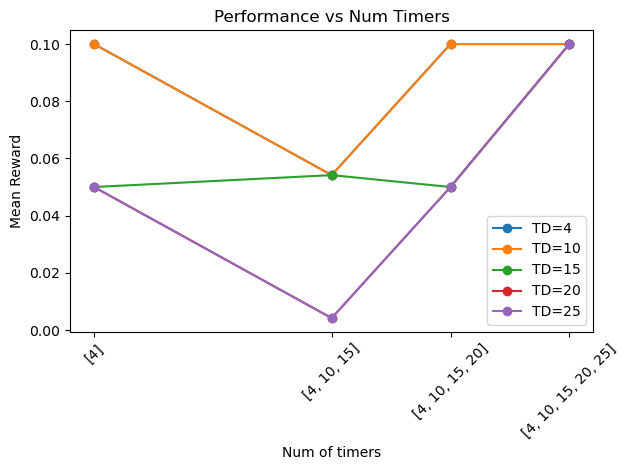

In [48]:
# average reward across td by num_timers
df_mean = task_performance.groupby(["num_timers", "TD"])["reward"].mean().reset_index()


pivot_df = df_mean.pivot(index="num_timers", columns="TD", values="reward")


plt.figure()

for td in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[td], marker='o', label=f"TD={td}")

x_vals = pivot_df.index.tolist()
x_labels = [str(oven_duration_list[:n]) for n in x_vals]

plt.xticks(x_vals, x_labels, rotation=45)

plt.xlabel("Num of timers")
plt.ylabel("Mean Reward")
plt.title("Performance vs Num Timers")
plt.legend()
plt.tight_layout()

plt.show()

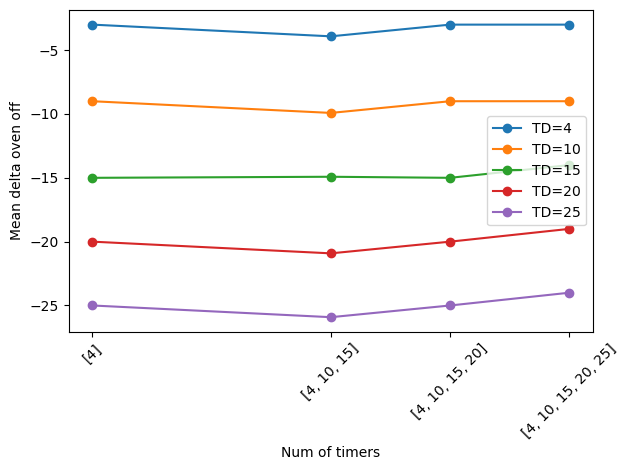

In [49]:
# average oven off across td by num_timers 
task_performance["delta_oven_off"] = task_performance.apply(lambda x: x["oven_off_time"]-x["TD"], axis=1)
df_mean = task_performance.groupby(["num_timers", "TD"])["delta_oven_off"].mean().reset_index()


pivot_df = df_mean.pivot(index="num_timers", columns="TD", values="delta_oven_off")


plt.figure()

for td in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[td], marker='o', label=f"TD={td}")

x_vals = pivot_df.index.tolist()
x_labels = [str(oven_duration_list[:n]) for n in x_vals]

plt.xticks(x_vals, x_labels, rotation=45)

plt.xlabel("Num of timers")
plt.ylabel("Mean delta oven off")
plt.legend()
plt.tight_layout()

plt.show()

In [60]:
# time steps needed for 1st timer 
# numtimers 1 - evn0, 2, , 3-env1, 4-env2, 5-env3, 6-env4, 7-env5
numtimers_envlabels = {1:0,2:0,3:1,4:2,5:3,6:4,7:5}
oven_duration_list = [4,10,15,20,25]
duration_list_id = "-".join(map(str, oven_duration_list))
lstm_size = 256
ent_coeff = 0
timestep = 200
g=0.99
rows = []
rows_traj = []
overcooked_buffer =2
models_folder = "/project_ghent/chronocooked/singleagent/train/multitimer_cl_tp_modelsv1"
# for target_duration in oven_duration_list:
for log in [1,2]:
    for num_timers in range(1,len(oven_duration_list)+1):
        if num_timers >= 2:
            continue
        # add log as param 
        if lstm_size == None:
            model_save_path = f"{models_folder}/v3_cl_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_buffer{overcooked_buffer}_logs{log}/"
        else:  
            model_save_path = f"{models_folder}/v3_cl_multitimer{duration_list_id}_tp_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_buffer{overcooked_buffer}_logs{log}/"

        model_files = os.listdir(model_save_path)
        max_training_ts = max([int(model_file.split("env")[1].split("_")[1])  if ("env" in model_file) and (model_file.split("env")[1].split("_")[0].isdigit()) and (int(model_file.split("env")[1].split("_")[0]) == numtimers_envlabels[num_timers]) else 0 for model_file in model_files])
        if max_training_ts == 0:
            print("No training timesteps found for num_timer", num_timers)
            continue
        print("max training timestep",max_training_ts, "log", log, "num timers", num_timers)
        if lstm_size == None:
            model = PPO.load(f"{model_save_path}/rl_model_env{numtimers_envlabels[num_timers]}_{max_training_ts}_steps.zip")
        else:
            model = RecurrentPPO.load(f"{model_save_path}/rl_model_env{numtimers_envlabels[num_timers]}_{max_training_ts}_steps.zip")
        for target_duration in oven_duration_list[:1]:
            env_test = MultiTimeProduction( oven_duration = target_duration, max_timesteps=timestep, num_timers=num_timers,
                                          undercooked_possible=True, overcooked_buffer=overcooked_buffer)
            model.set_env(env_test)
            for s_i, seed in enumerate(seeds.values()):
                obs, _ = env_test.reset(seed=seed)
                visual_obs = np.sum(obs,axis=2)
                obs_concat = [visual_obs]
                act_concat = []
                reward_concat = []
                adj_oven = []
                oven_timers = []
                # print("oven timers", env_test.oven1_timer, env_test.oven2_timer)
                rewards=0
                states = None
                for i in range(timestep + 2):
                    # obs = obs + 300
                    action, states = model.predict(obs, state=states, deterministic=True) 
                    act_concat.append(action)
                    adjacent_cells = env_test.get_adjacent_cells(env_test.agent_position)
                    if env_test.oven_pos in adjacent_cells.keys():
                        adj_oven.append(1)
                    else:
                        adj_oven.append(1)
                    # print(visual_obs)
                    # print("action",action)
                    oven_timers.append(env_test.oven_timer)
                    obs, reward, done, _ ,_= env_test.step(action)
                    visual_obs = np.sum(obs,axis=2)
                    obs_concat.append(visual_obs)

                
                    # print("reward",reward)
                    # print("oven_off_time",env_test.oven_off_time)
                    
                    rewards += reward
                    reward_concat.append(reward)
                    if done:
                        
                        act_concat.append(0)
                        reward_concat.append(0)

                        
                        rows.append({"TD":target_duration, "p_id":log, "seed":s_i,
                                     "num_timers":num_timers,"reward":reward, "oven_off_time":env_test.oven_off_time,
                                    "delta_oven_off":env_test.oven_off_time - target_duration})
                        rows_traj.append({"TD":target_duration, "p_id":log, "seed":s_i,"num_timers":num_timers,"reward":reward,
                                         "act_concat":act_concat,"obs_concat":obs_concat,"reward_concat":reward_concat})
                        # print("oven duration", env_test.oven_duration,"rewards",rewards)
                        obs,_ = env_test.reset()
                        break

            # if target_duration==24:
                # break
        # break
task_performance = pd.DataFrame(rows)
task_performance

max training timestep 240000 log 1 num timers 1
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
max training timestep 200000 log 2 num timers 1
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


,TD,p_id,seed,num_timers,reward,oven_off_time,delta_oven_off
0,4,1,0,1,0.0,1,-3
1,4,1,1,1,0.1,1,-3
2,4,1,2,1,1.0,4,0
3,4,1,3,1,0.1,1,-3
4,4,1,4,1,1.0,3,-1
5,4,1,5,1,1.0,2,-2
6,4,1,6,1,0.0,-1,-5
7,4,1,7,1,1.0,2,-2
8,4,1,8,1,0.1,-1,-5
9,4,1,9,1,1.0,2,-2
